In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Underatanding and EDA

## Basics of cybersecurity and intrusion detection systems

Cybersecurity is basically: Protecting computers, networks, and data from unwanted access or attacks.
Think of a system like a house:

•	Doors = network ports  
•	People entering = data packets 
•	Thieves = attackers 

Your job: Make sure only the right “people” enter.

An intrusion =Someone trying to break into or misuse a system

Examples:
•	Sending too many requests → crash server (DoS attack) 
•	Guessing passwords repeatedly 
•	Sending malicious data


What is an Intrusion Detection System (IDS)?
An IDS is like a security guard with binoculars 
It doesn’t block directly. It:
•	Monitors traffic 
•	Detects suspicious activity 
•	Raises an alert


An Intrusion Detection System (IDS) is a security tool that monitors network traffic or system activities to detect unauthorized access or suspicious behavior. Think of it as a "watchdog" that looks for signs of cyber attacks or security breaches, helping administrators respond quickly before damage occurs.

•	Intrusion: Unauthorized access to a system, often by cybercriminals using advanced techniques.
•	IDS Functions: Monitors traffic for unusual activities and alerts administrators when potential attacks are detected.
•	Detection Focus: IDS looks for abnormal behavior that could harm data integrity, confidentiality or availability.

Common Methods of Intrusion
•	Address Spoofing: Hiding the source of an attack by using fake or unsecured proxy servers making it hard to identify the attacker.
•	Fragmentation: Sending data in small pieces to slip past detection systems.
•	Pattern Evasion: Changing attack methods to avoid detection by IDS systems that look for specific patterns.
•	Coordinated Attack: Using multiple attackers or ports to scan a network, confusing the IDS and making hard to see what is happening.

Working IDS
An IDS operates by monitoring network traffic or system activities to detect suspicious or malicious actions. Here’s how it works:
•	Traffic Monitoring: The IDS captures and monitors data flowing through the network
•	Pattern Matching: It compares the incoming data against a set of predefined rules/patterns that could indicate attacks/intrusions.
•	Alerting: If the system detects an activity that matches any of these patterns, triggers an alert to notify the system administrator.
•	Administrator Action: Upon receiving the alert, the administrator can investigate the source of the potential attack and take necessary actions to mitigate the risk.


In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer, FunctionTransformer
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score,
                             roc_curve, auc, RocCurveDisplay)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
import warnings
warnings.filterwarnings('ignore')


## Load Dataset and explore structure

In [97]:
COLUMNS = ['duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
           'wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised',
           'root_shell','su_attempted','num_root','num_file_creations','num_shells',
           'num_access_files','num_outbound_cmds','is_host_login','is_guest_login',
           'count','srv_count','serror_rate','srv_serror_rate','rerror_rate',
           'srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate',
           'dst_host_count','dst_host_srv_count','dst_host_same_srv_rate',
           'dst_host_diff_srv_rate','dst_host_same_src_port_rate',
           'dst_host_srv_diff_host_rate','dst_host_serror_rate',
           'dst_host_srv_serror_rate','dst_host_rerror_rate',
           'dst_host_srv_rerror_rate','attack_class','level']

df = pd.read_csv('/kaggle/input/datasets/hassan06/nslkdd/KDDTrain+.txt',
                 header=None, names=COLUMNS)

print("Dataset loaded successfully")
print(f"Shape: {df.shape}")
df.head()

Dataset loaded successfully
Shape: (125973, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_class,level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [98]:
print("="*60)
print("DATASET INFO")
print("="*60)
df.info()

print("\n" + "="*60)
print("STATISTICAL SUMMARY")
print("="*60)
df.describe().T

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null 

,count,mean,std,min,25%,50%,75%,max
duration,125973.0,287.144650,2.604515e+03,0.0,0.00,0.00,0.00,4.290800e+04
src_bytes,125973.0,45566.743000,5.870331e+06,0.0,0.00,44.00,276.00,1.379964e+09
dst_bytes,125973.0,19779.114421,4.021269e+06,0.0,0.00,0.00,516.00,1.309937e+09
land,125973.0,0.000198,1.408607e-02,0.0,0.00,0.00,0.00,1.000000e+00
wrong_fragment,125973.0,0.022687,2.535300e-01,0.0,0.00,0.00,0.00,3.000000e+00
urgent,125973.0,0.000111,1.436603e-02,0.0,0.00,0.00,0.00,3.000000e+00
hot,125973.0,0.204409,2.149968e+00,0.0,0.00,0.00,0.00,7.700000e+01
num_failed_logins,125973.0,0.001222,4.523914e-02,0.0,0.00,0.00,0.00,5.000000e+00
logged_in,125973.0,0.395736,4.890101e-01,0.0,0.00,0.00,1.00,1.000000e+00
num_compromised,125973.0,0.279250,2.394204e+01,0.0,0.00,0.00,0.00,7.479000e+03


In [99]:
print("="*60)
print("MISSING VALUES")
print("="*60)
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found")

print("\n" + "="*60)
print("DUPLICATE ROWS")
print("="*60)
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")
print("No duplicates " if dupes == 0 else f" {dupes} duplicates found")

MISSING VALUES
No missing values found

DUPLICATE ROWS
Duplicate rows: 0
No duplicates 


In [100]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns: {cat_cols}\n")

for col in cat_cols:
    print(f"Column: {col}  ({df[col].nunique()} unique values)")
    print(df[col].value_counts())
    print("-"*40)

Categorical columns: ['protocol_type', 'service', 'flag', 'attack_class']

Column: protocol_type  (3 unique values)
protocol_type
tcp     102689
udp      14993
icmp      8291
Name: count, dtype: int64
----------------------------------------
Column: service  (70 unique values)
service
http         40338
private      21853
domain_u      9043
smtp          7313
ftp_data      6860
             ...  
tftp_u           3
http_8001        2
aol              2
harvest          2
http_2784        1
Name: count, Length: 70, dtype: int64
----------------------------------------
Column: flag  (11 unique values)
flag
SF        74945
S0        34851
REJ       11233
RSTR       2421
RSTO       1562
S1          365
SH          271
S2          127
RSTOS0      103
S3           49
OTH          46
Name: count, dtype: int64
----------------------------------------
Column: attack_class  (23 unique values)
attack_class
normal             67343
neptune            41214
satan               3633
ipsweep         

## Perform Exploratory Data Analysis(EDA)

### Visualize class Distribution and feature relationships

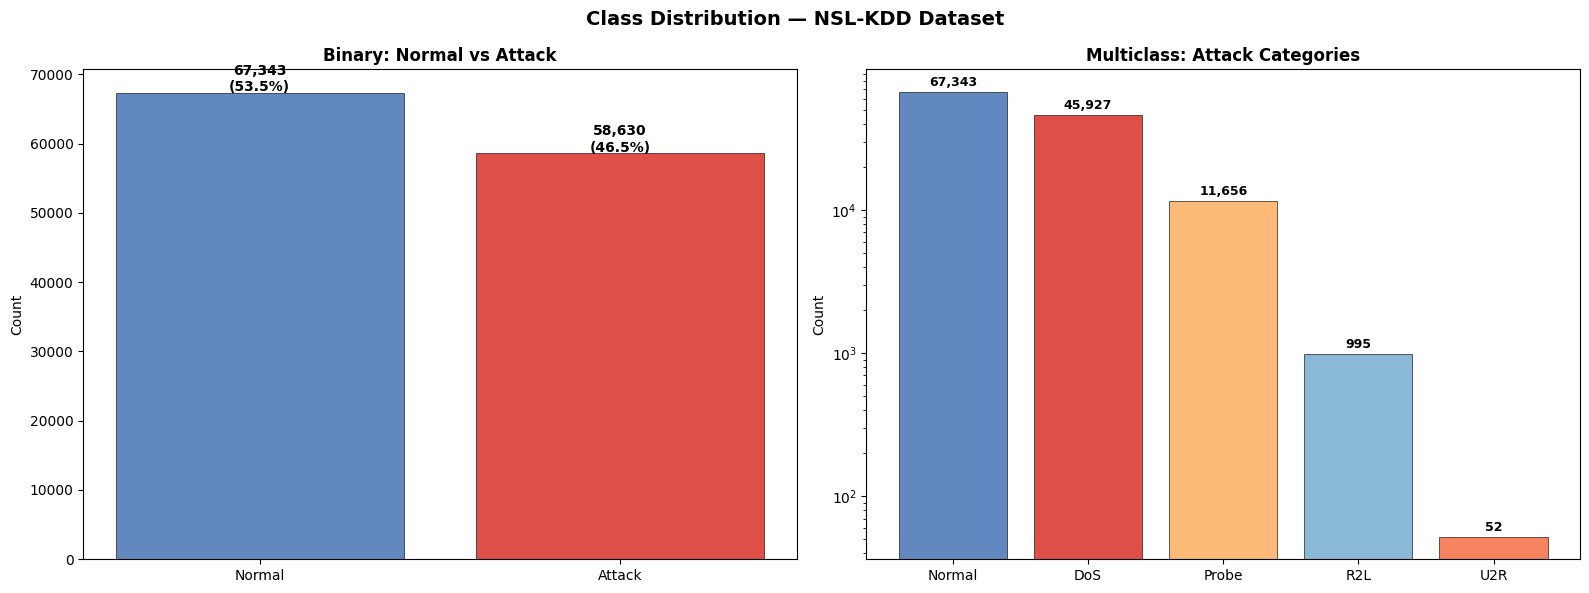

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Class Distribution — NSL-KDD Dataset', fontweight='bold', fontsize=14)

# Binary: normal vs attack
binary = df['attack_class'].apply(lambda x: 'Normal' if x.strip() == 'normal' else 'Attack')
binary_counts = binary.value_counts()

axes[0].bar(binary_counts.index, binary_counts.values,
            color=['#4575b4', '#d73027'], alpha=0.85, edgecolor='black', linewidth=0.5)
axes[0].set_title('Binary: Normal vs Attack', fontweight='bold')
axes[0].set_ylabel('Count')
for i, (label, val) in enumerate(binary_counts.items()):
    axes[0].text(i, val + 200, f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontweight='bold')

# Multiclass: attack categories
attack_map = {
    'normal': 'Normal',
    'back':'DoS','land':'DoS','neptune':'DoS','pod':'DoS','smurf':'DoS',
    'teardrop':'DoS','mailbomb':'DoS','processtable':'DoS','udpstorm':'DoS',
    'apache2':'DoS','worm':'DoS',
    'ipsweep':'Probe','nmap':'Probe','portsweep':'Probe','satan':'Probe',
    'mscan':'Probe','saint':'Probe',
    'ftp_write':'R2L','guess_passwd':'R2L','imap':'R2L','multihop':'R2L',
    'phf':'R2L','spy':'R2L','warezclient':'R2L','warezmaster':'R2L',
    'sendmail':'R2L','named':'R2L','snmpgetattack':'R2L','snmpguess':'R2L',
    'xlock':'R2L','xsnoop':'R2L','httptunnel':'R2L',
    'buffer_overflow':'U2R','loadmodule':'U2R','perl':'U2R','rootkit':'U2R',
    'ps':'U2R','sqlattack':'U2R','xterm':'U2R',
}
multi = df['attack_class'].str.strip().map(attack_map)
multi_counts = multi.value_counts()

colors = ['#4575b4','#d73027','#fdae61','#74add1','#f46d43']
axes[1].bar(multi_counts.index, multi_counts.values,
            color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)
axes[1].set_title('Multiclass: Attack Categories', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_yscale('log')   # log scale because U2R is tiny
for i, (label, val) in enumerate(multi_counts.items()):
    axes[1].text(i, val * 1.1, f'{val:,}', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('week1_class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

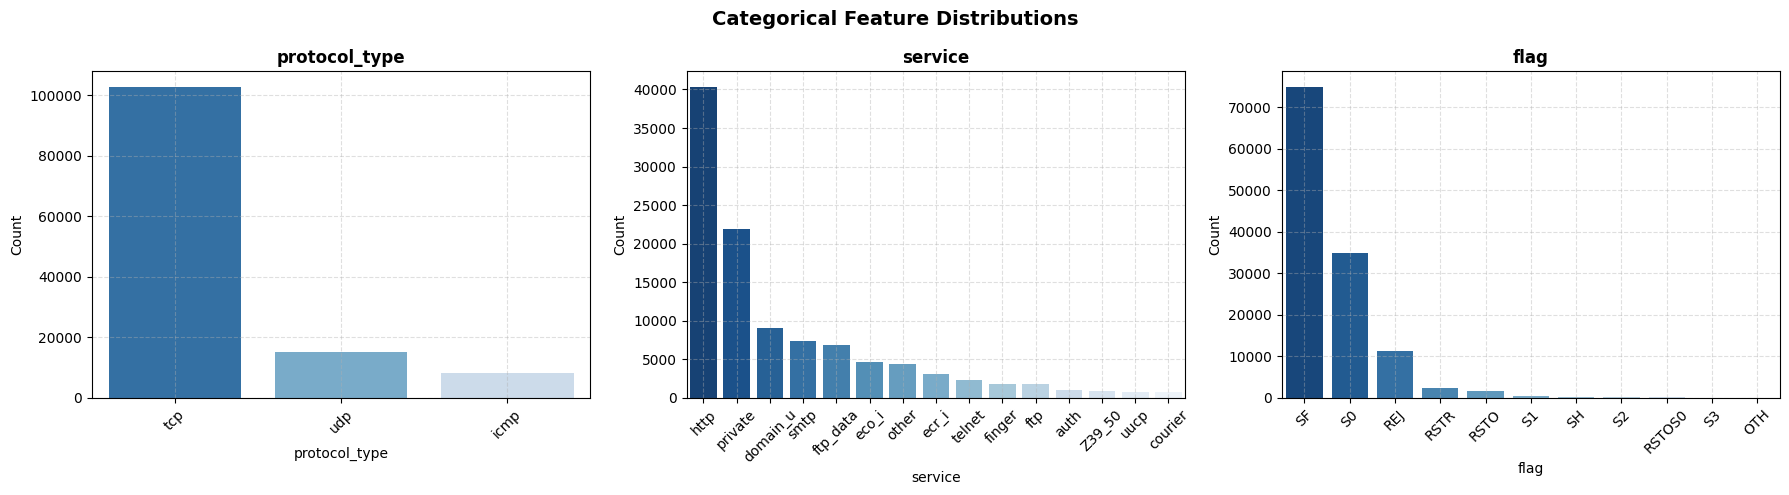

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Categorical Feature Distributions', fontweight='bold', fontsize=14)

for ax, col in zip(axes, ['protocol_type', 'service', 'flag']):
    counts = df[col].value_counts().head(15)  # top 15 for service
    sns.barplot(x=counts.index, y=counts.values, ax=ax,
                palette='Blues_r')
    ax.set_title(f'{col}', fontweight='bold')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('week1_categorical_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

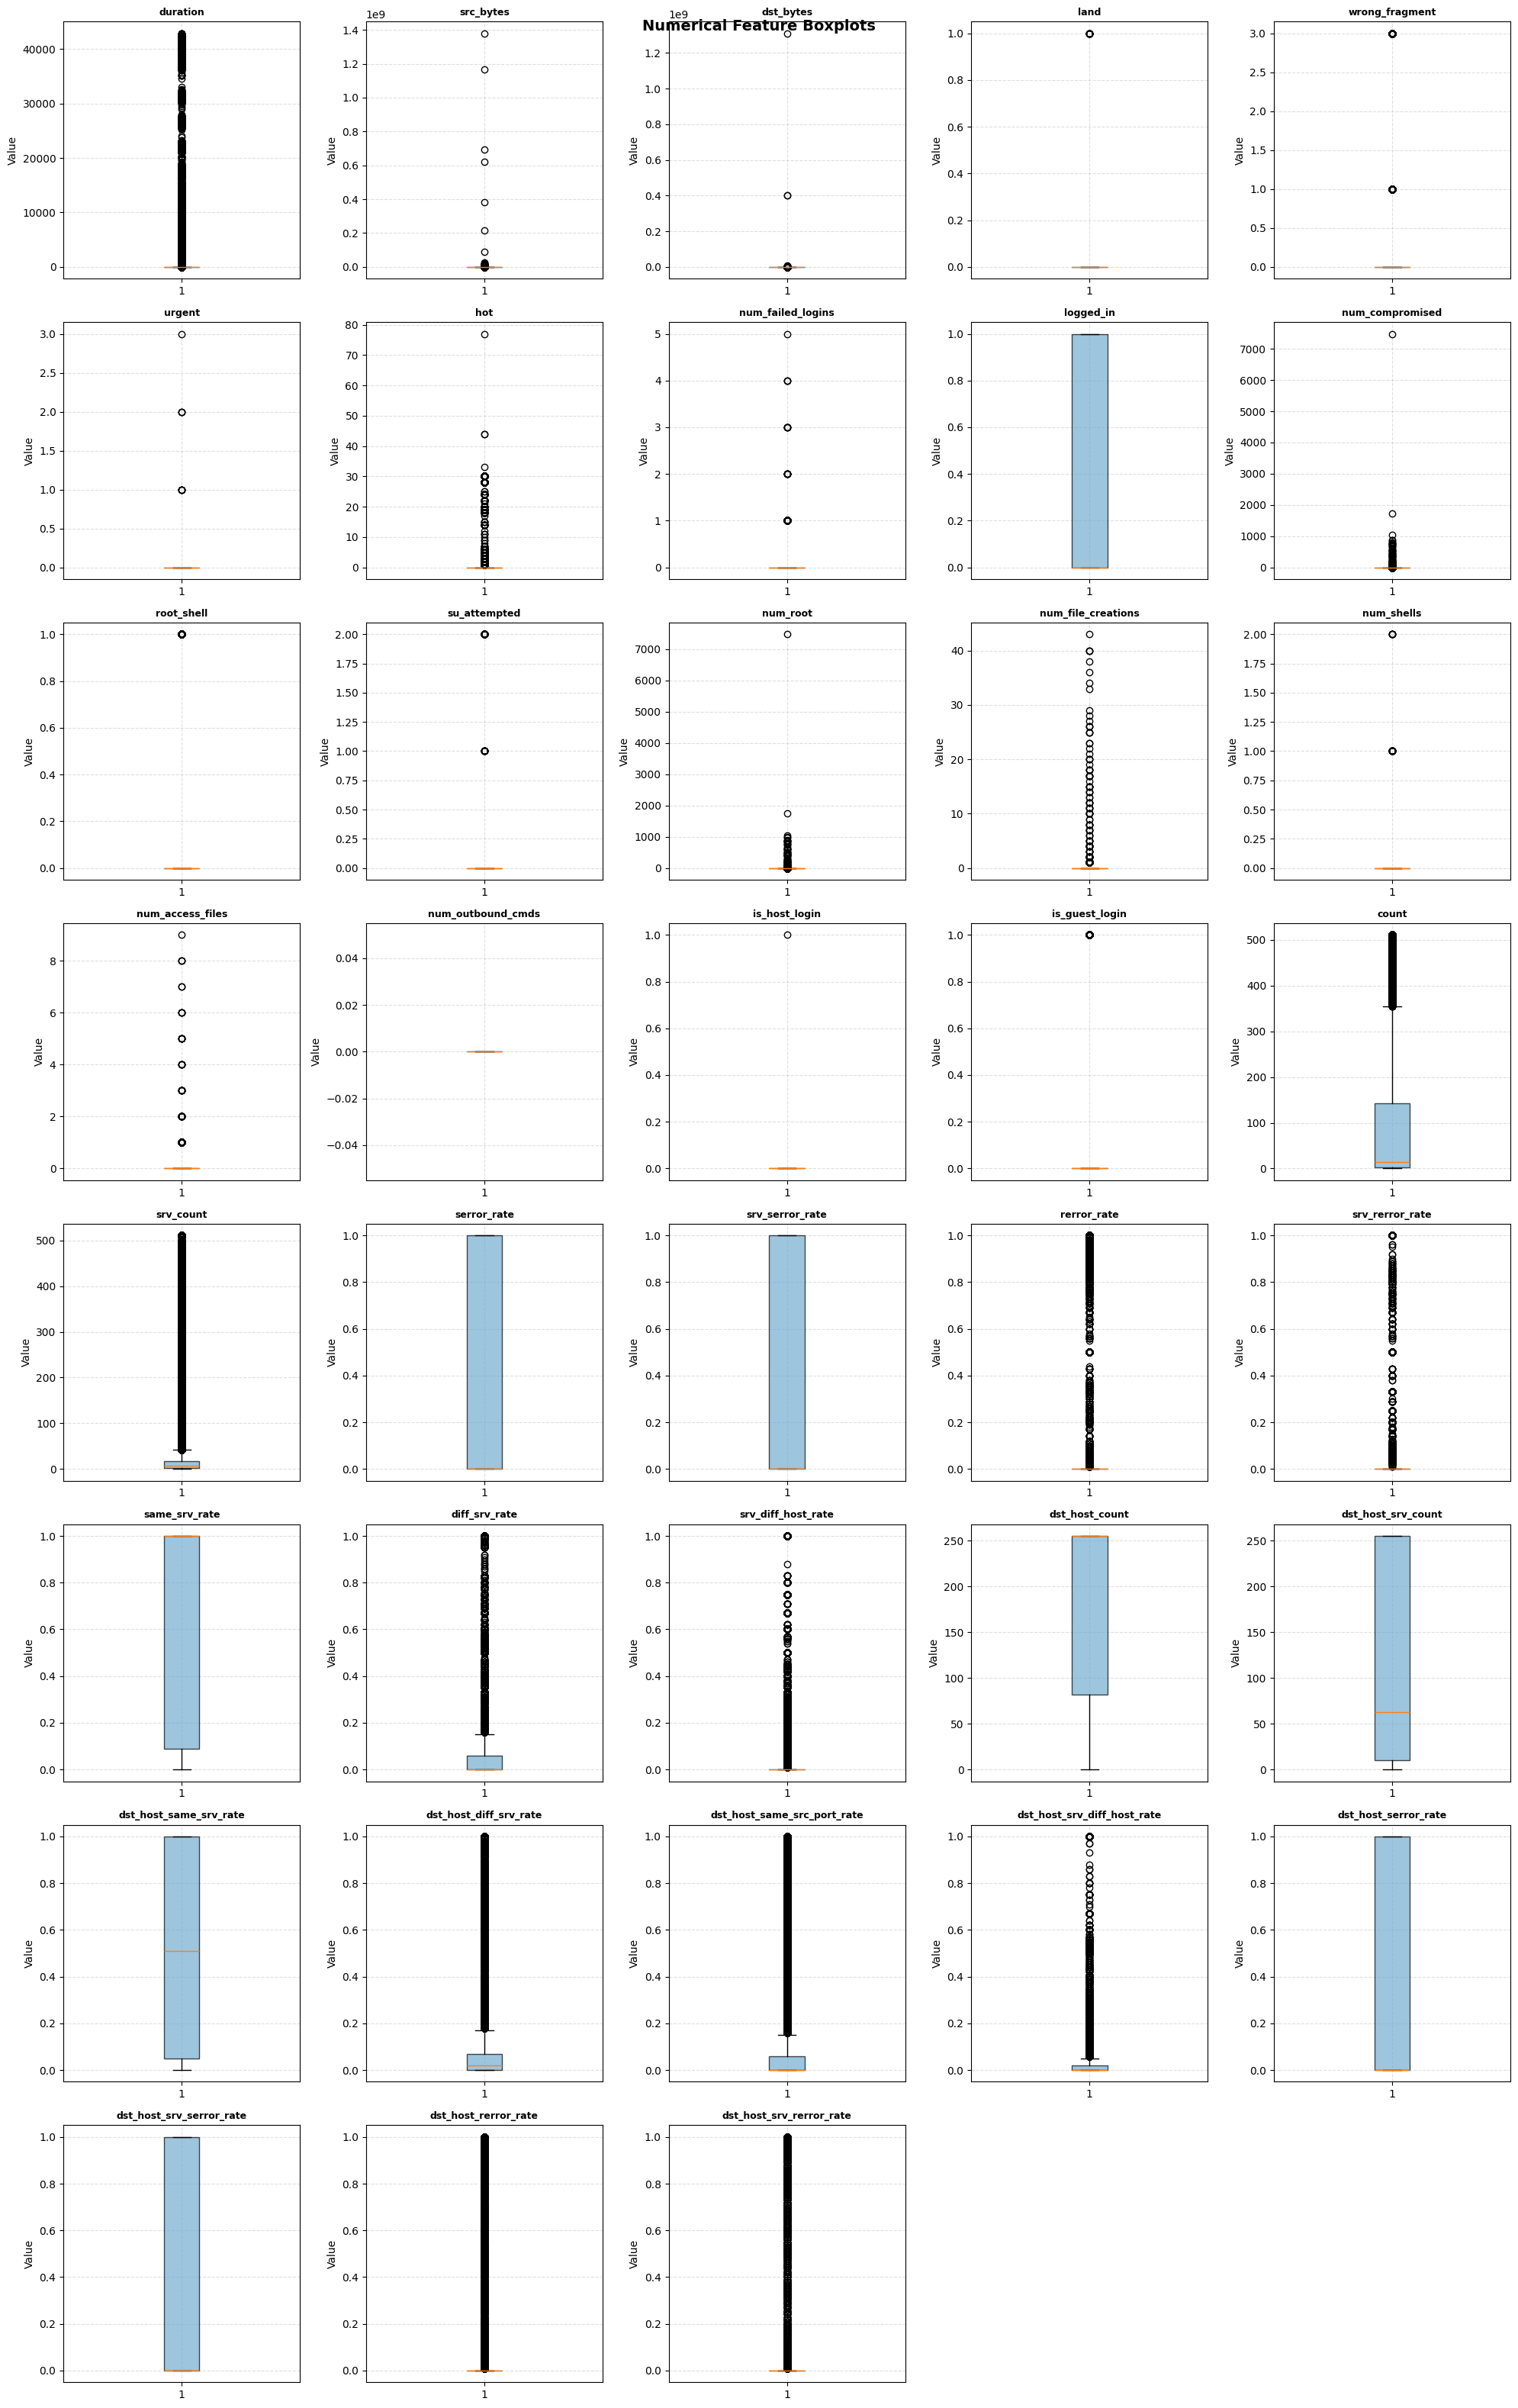

In [102]:
num_cols = df.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c != 'level']

n_cols = 5
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
fig.suptitle('Numerical Feature Boxplots', fontweight='bold', fontsize=14)
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#74add1', alpha=0.7))
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].grid(True, linestyle='--', alpha=0.4)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('week1_boxplots.png', dpi=120, bbox_inches='tight')
plt.show()

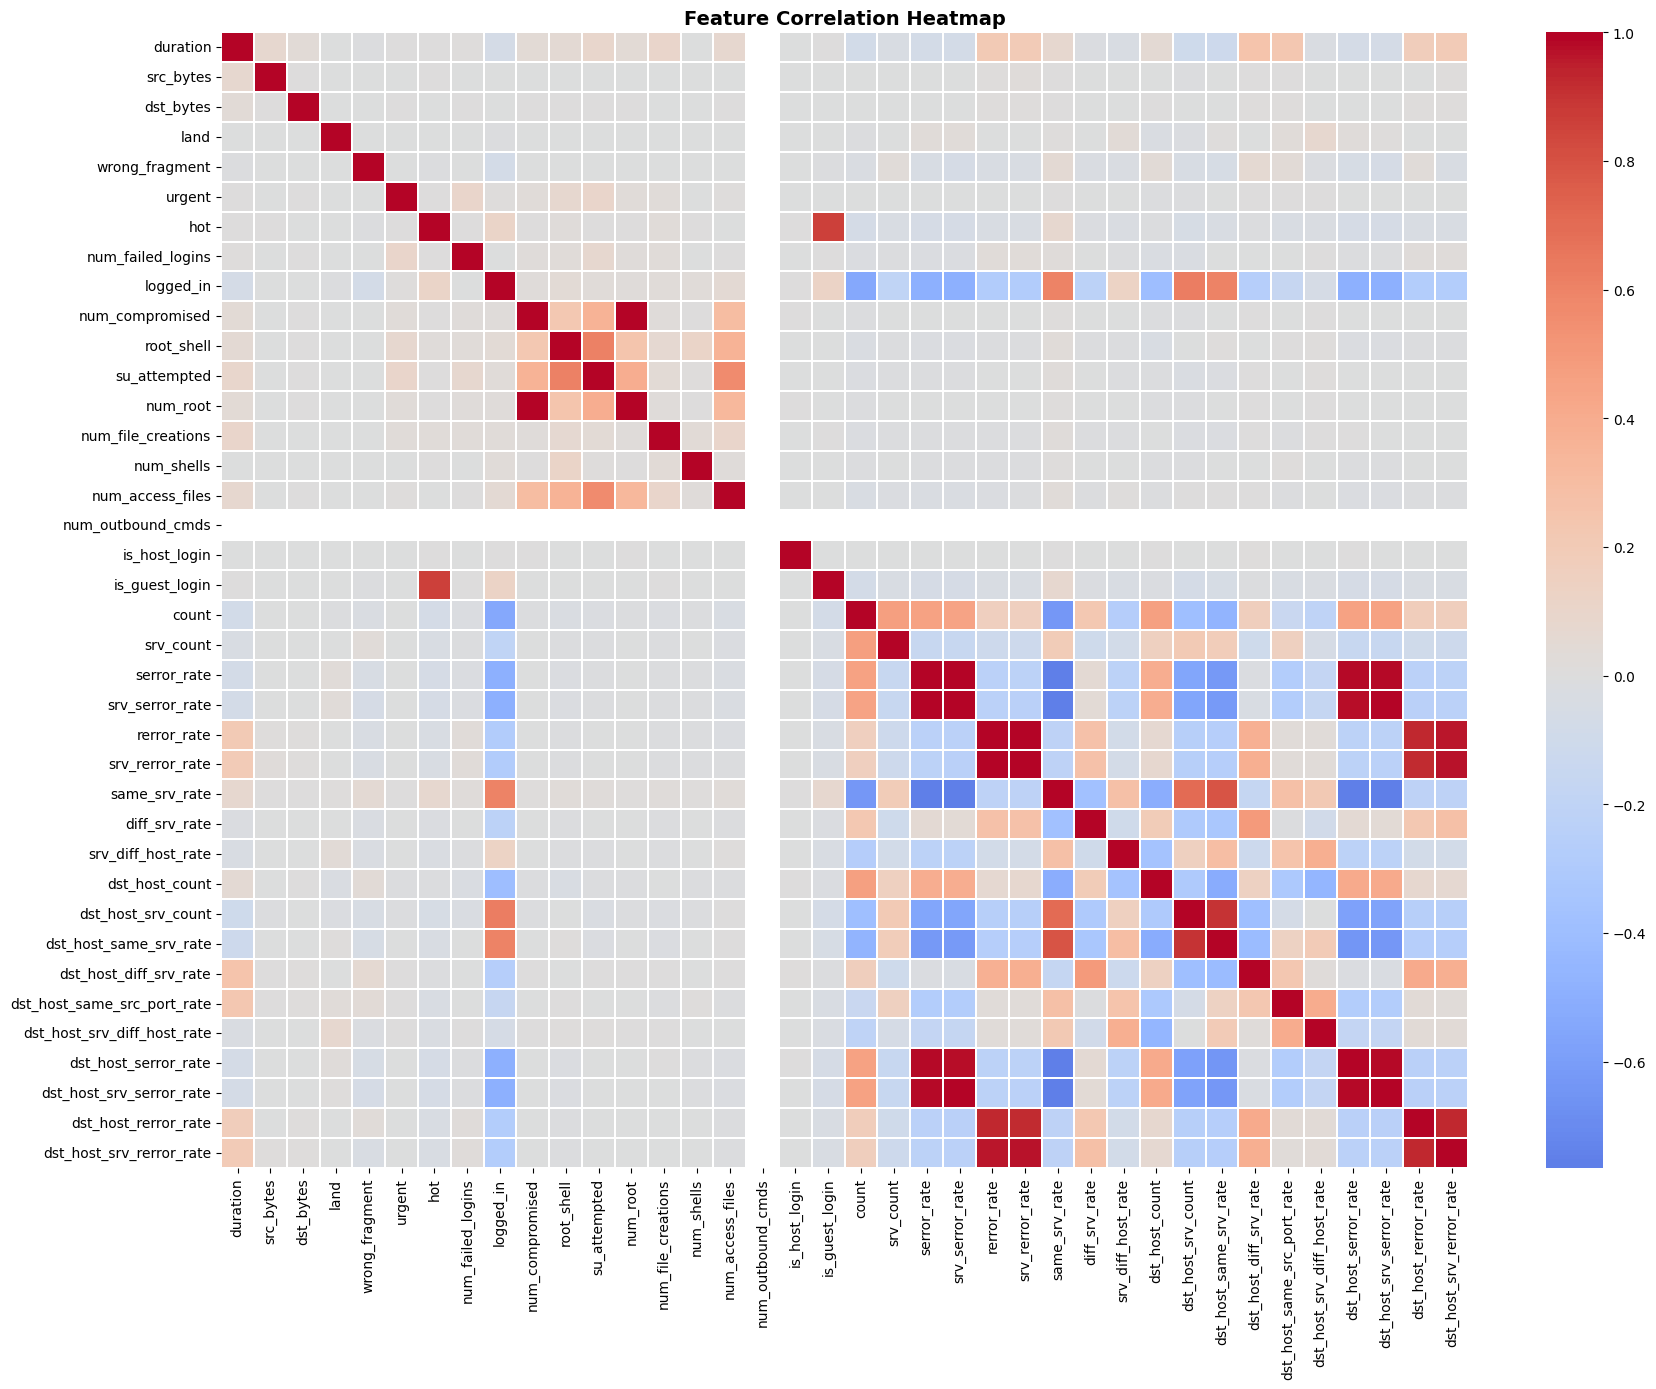

In [103]:
fig, ax = plt.subplots(figsize=(18, 14))
corr = df[num_cols].corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False,
            linewidths=0.3, ax=ax)
ax.set_title('Feature Correlation Heatmap', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('week1_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

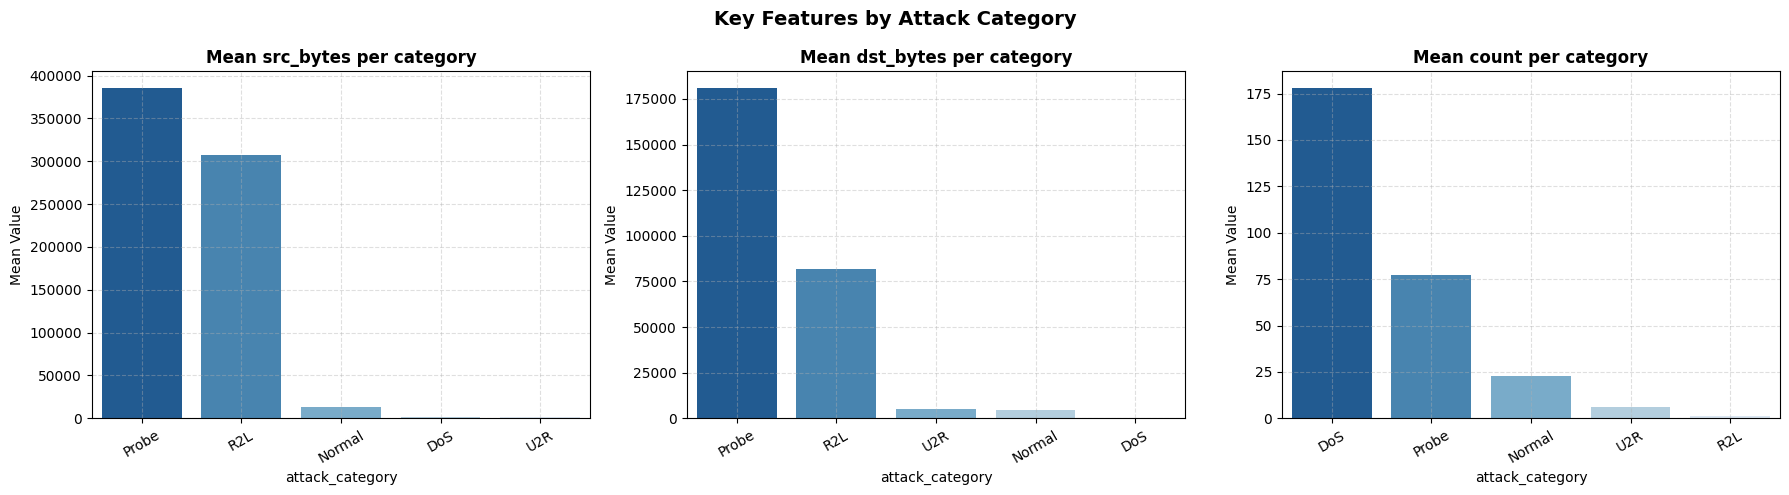


 WEEK 1 COMPLETE
   Dataset shape    : (125973, 44)
   Missing values   : 0
   Duplicate rows   : 0
   Attack categories: ['DoS', 'Normal', 'Probe', 'R2L', 'U2R']


In [104]:
df['attack_category'] = df['attack_class'].str.strip().map(attack_map)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Key Features by Attack Category', fontweight='bold', fontsize=14)

for ax, feat in zip(axes, ['src_bytes', 'dst_bytes', 'count']):
    means = df.groupby('attack_category')[feat].mean().sort_values(ascending=False)
    sns.barplot(x=means.index, y=means.values, ax=ax, palette='Blues_r')
    ax.set_title(f'Mean {feat} per category', fontweight='bold')
    ax.set_ylabel('Mean Value')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('week1_feature_by_category.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n WEEK 1 COMPLETE")
print(f"   Dataset shape    : {df.shape}")
print(f"   Missing values   : {df.isnull().sum().sum()}")
print(f"   Duplicate rows   : {df.duplicated().sum()}")
print(f"   Attack categories: {sorted(multi.unique())}")

# Data Preprocessing

In [105]:
print("="*60)
print(" WEEK 2: DATA PREPROCESSING")
print("="*60)
print(f"Starting shape: {df.shape}")

 WEEK 2: DATA PREPROCESSING
Starting shape: (125973, 44)


In [106]:
# ════════════════════════════════════════════════════════════════
# STEP 1: DROP CONSTANT COLUMNS
# Columns with only 1 unique value carry zero information
# ════════════════════════════════════════════════════════════════

num_cols      = df.select_dtypes(include='number').columns.tolist()
constant_cols = [c for c in num_cols if df[c].nunique() <= 1]

print("\n── STEP 1: Drop Constant Columns ──")
print(f"Found   : {constant_cols}")
df.drop(columns=constant_cols, inplace=True)
print(f"Dropped : {constant_cols}")
print(f"Shape   : {df.shape}")


── STEP 1: Drop Constant Columns ──
Found   : ['num_outbound_cmds']
Dropped : ['num_outbound_cmds']
Shape   : (125973, 43)



── STEP 2: Drop Redundant Correlated Columns (threshold > 0.95) ──

Correlated pairs found:
  num_compromised                     ↔  num_root                             =  0.9988
  serror_rate                         ↔  srv_serror_rate                      =  0.9933
  rerror_rate                         ↔  srv_rerror_rate                      =  0.9890
  serror_rate                         ↔  dst_host_serror_rate                 =  0.9794
  srv_serror_rate                     ↔  dst_host_serror_rate                 =  0.9776
  serror_rate                         ↔  dst_host_srv_serror_rate             =  0.9811
  srv_serror_rate                     ↔  dst_host_srv_serror_rate             =  0.9863
  dst_host_serror_rate                ↔  dst_host_srv_serror_rate             =  0.9851
  rerror_rate                         ↔  dst_host_srv_rerror_rate             =  0.9644
  srv_rerror_rate                     ↔  dst_host_srv_rerror_rate             =  0.9702

Dropped : ['num_root', 'sr

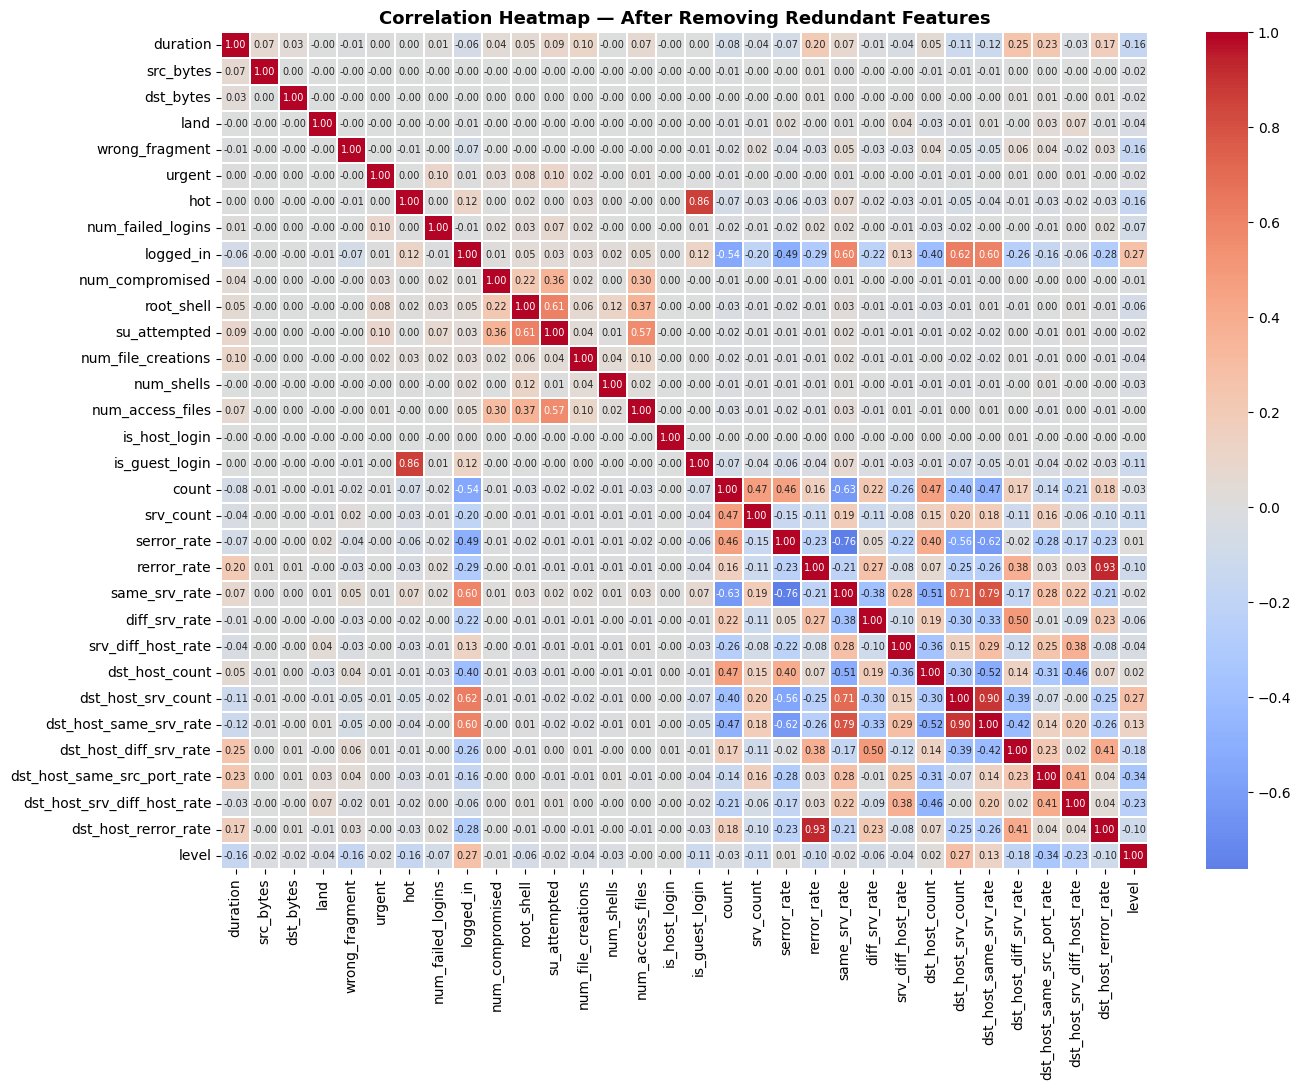

In [107]:
# ════════════════════════════════════════════════════════════════
# STEP 2: DROP HIGHLY CORRELATED (REDUNDANT) COLUMNS
# Columns with correlation > 0.95 are redundant
# ════════════════════════════════════════════════════════════════

print("\n── STEP 2: Drop Redundant Correlated Columns (threshold > 0.95) ──")

num_cols    = df.select_dtypes(include='number').columns.tolist()
corr_matrix = df[num_cols].corr().abs()
upper       = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
THRESHOLD   = 0.95

print(f"\nCorrelated pairs found:")
pairs = []
for col in upper.columns:
    for row in upper.index:
        val = upper.loc[row, col]
        if val > THRESHOLD:
            pairs.append((row, col, round(val, 4)))
            print(f"  {row:35s} ↔  {col:35s}  =  {val:.4f}")

redundant_cols = [col for col in upper.columns if any(upper[col] > THRESHOLD)]
df.drop(columns=redundant_cols, inplace=True)
print(f"\nDropped : {redundant_cols}")
print(f"Shape   : {df.shape}")

# ── Visualise correlation heatmap AFTER dropping ──
fig, ax = plt.subplots(figsize=(14, 11))
remaining_num = df.select_dtypes(include='number').columns.tolist()
sns.heatmap(df[remaining_num].corr(), cmap='coolwarm', annot=True,
            fmt=".2f", annot_kws={"size": 7}, center=0,
            linewidths=0.3, ax=ax)
ax.set_title("Correlation Heatmap — After Removing Redundant Features",
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('week2_correlation_after.png', dpi=120, bbox_inches='tight')
plt.show()

## Handle categorical variables (encoding)

In [108]:
# ════════════════════════════════════════════════════════════════
# STEP 3: FEATURE ENGINEERING — GROUP CATEGORICAL VALUES
# Map 70+ services → 9 meaningful categories
# Map 11 flags     → 4 meaningful categories
# ════════════════════════════════════════════════════════════════

print("\n── STEP 3: Categorical Feature Engineering ──")

service_map = {
    'http':'web','http_443':'web','http_8001':'web','http_2784':'web',
    'ftp':'file_transfer','ftp_data':'file_transfer','tftp_u':'file_transfer',
    'uucp':'file_transfer','uucp_path':'file_transfer',
    'smtp':'mail','pop_3':'mail','pop_2':'mail','imap4':'mail',
    'telnet':'remote_access','ssh':'remote_access','remote_job':'remote_access',
    'login':'remote_access','shell':'remote_access','klogin':'remote_access',
    'kshell':'remote_access',
    'domain':'dns_network','domain_u':'dns_network','ntp_u':'dns_network',
    'bgp':'dns_network','netstat':'dns_network','hostnames':'dns_network',
    'whois':'dns_network',
    'auth':'authentication','ldap':'authentication',
    'IRC':'communication','nnsp':'communication','nntp':'communication',
    'sql_net':'database_rpc','sunrpc':'database_rpc',
    'finger':'system_services','time':'system_services','daytime':'system_services',
    'echo':'system_services','printer':'system_services','systat':'system_services',
    'supdup':'system_services','discard':'system_services','exec':'system_services',
    'link':'system_services','name':'system_services','gopher':'system_services',
    'efs':'system_services','vmnet':'system_services','Z39_50':'system_services',
    'X11':'system_services','csnet_ns':'system_services','netbios_dgm':'system_services',
    'netbios_ssn':'system_services','netbios_ns':'system_services',
    'iso_tsap':'system_services','mtp':'system_services','courier':'system_services',
    'ctf':'system_services','rje':'system_services',
    'eco_i':'attack_related','ecr_i':'attack_related','urp_i':'attack_related',
    'urh_i':'attack_related','red_i':'attack_related','tim_i':'attack_related',
    'pm_dump':'attack_related',
    'private':'miscellaneous','other':'miscellaneous','aol':'miscellaneous',
    'harvest':'miscellaneous'
}

flag_map = {
    'SF' :'successful_connection',
    'S0' :'failed_connection','REJ':'failed_connection',
    'RSTO':'failed_connection','RSTR':'failed_connection','RSTOS0':'failed_connection',
    'S1' :'partial_connection','S2':'partial_connection','S3':'partial_connection',
    'SH' :'abnormal_connection','OTH':'abnormal_connection'
}

df['service_category'] = df['service'].map(service_map)
df['flag_category']    = df['flag'].map(flag_map)
df.drop(columns=['service', 'flag'], inplace=True)

print(f"service → service_category : {df['service_category'].nunique()} categories")
print(f"flag    → flag_category    : {df['flag_category'].nunique()} categories")
print(df['service_category'].value_counts())


── STEP 3: Categorical Feature Engineering ──
service → service_category : 11 categories
flag    → flag_category    : 4 categories
service_category
web                40871
miscellaneous      26216
system_services    13127
dns_network        12003
file_transfer      10086
mail                8302
attack_related      8296
remote_access       3968
authentication      1365
communication       1113
database_rpc         626
Name: count, dtype: int64


In [109]:
# ════════════════════════════════════════════════════════════════
# STEP 4: CREATE TARGET COLUMNS
# Binary  : normal vs attack
# Multiclass: DoS, Probe, R2L, U2R, Normal
# ════════════════════════════════════════════════════════════════

print("\n── STEP 4: Create Target Columns ──")

attack_map = {
    'normal': 'Normal',
    'back':'DoS','land':'DoS','neptune':'DoS','pod':'DoS','smurf':'DoS',
    'teardrop':'DoS','mailbomb':'DoS','processtable':'DoS','udpstorm':'DoS',
    'apache2':'DoS','worm':'DoS',
    'ipsweep':'Probe','nmap':'Probe','portsweep':'Probe','satan':'Probe',
    'mscan':'Probe','saint':'Probe',
    'ftp_write':'R2L','guess_passwd':'R2L','imap':'R2L','multihop':'R2L',
    'phf':'R2L','spy':'R2L','warezclient':'R2L','warezmaster':'R2L',
    'sendmail':'R2L','named':'R2L','snmpgetattack':'R2L','snmpguess':'R2L',
    'xlock':'R2L','xsnoop':'R2L','httptunnel':'R2L',
    'buffer_overflow':'U2R','loadmodule':'U2R','perl':'U2R','rootkit':'U2R',
    'ps':'U2R','sqlattack':'U2R','xterm':'U2R',
}

# Binary target
df['attack_binary'] = df['attack_class'].apply(
    lambda x: 0 if x.strip() == 'normal' else 1
)

# Multiclass target
df['attack_multi'] = df['attack_class'].str.strip().map(attack_map)

# Drop original columns not needed for modelling
df.drop(columns=['attack_class', 'level', 'attack_category'], inplace=True)

print(f"Binary target   — 0: Normal, 1: Attack")
print(df['attack_binary'].value_counts())
print(f"\nMulticlass target:")
print(df['attack_multi'].value_counts())


── STEP 4: Create Target Columns ──
Binary target   — 0: Normal, 1: Attack
attack_binary
0    67343
1    58630
Name: count, dtype: int64

Multiclass target:
attack_multi
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


In [110]:
# ════════════════════════════════════════════════════════════════
# STEP 5: LABEL ENCODE ALL CATEGORICAL COLUMNS
# ════════════════════════════════════════════════════════════════

print("\n── STEP 5: Label Encoding ──")

le = LabelEncoder()
for col in ['protocol_type', 'service_category', 'flag_category']:
    df[col] = le.fit_transform(df[col])
    print(f"  {col} encoded ")

# Encode multiclass target — save encoder for later
le_multi = LabelEncoder()
df['attack_multi'] = le_multi.fit_transform(df['attack_multi'])
print(f"\nMulticlass classes: {le_multi.classes_}")

# Verify all columns are now numeric
non_numeric = df.select_dtypes(exclude='number').columns.tolist()
print(f"\nNon-numeric columns remaining: {non_numeric if non_numeric else 'None '}")
print(f"Shape: {df.shape}")


── STEP 5: Label Encoding ──
  protocol_type encoded 
  service_category encoded 
  flag_category encoded 

Multiclass classes: ['DoS' 'Normal' 'Probe' 'R2L' 'U2R']

Non-numeric columns remaining: None 
Shape: (125973, 36)



 Class Imbalance Visualisation 


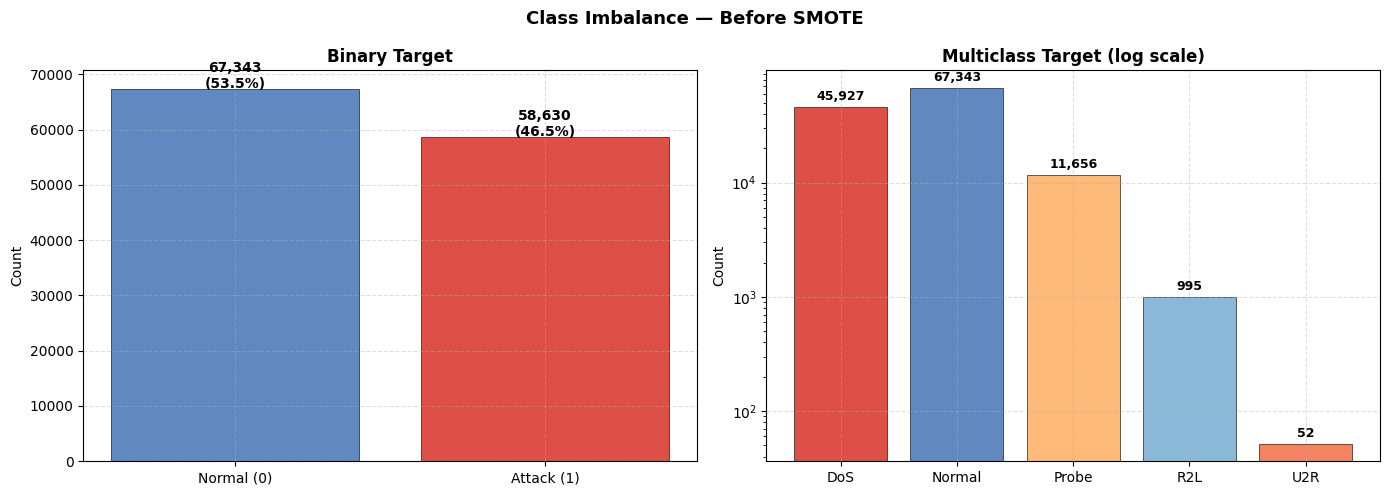


Key observation:
  Normal : 67,343 rows
  DoS    : 45,927 rows
  Probe  : 11,656 rows
  R2L    : 995 rows  ← severely underrepresented
  U2R    : 52 rows  ← severely underrepresented


In [111]:
# ════════════════════════════════════════════════════════════════
# VISUALISE CLASS IMBALANCE
# ════════════════════════════════════════════════════════════════

print("\n Class Imbalance Visualisation ")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Class Imbalance — Before SMOTE', fontweight='bold', fontsize=13)

# Binary
binary_counts = df['attack_binary'].value_counts()
axes[0].bar(['Normal (0)', 'Attack (1)'], binary_counts.values,
            color=['#4575b4', '#d73027'], alpha=0.85, edgecolor='black', linewidth=0.5)
axes[0].set_title('Binary Target', fontweight='bold')
axes[0].set_ylabel('Count')
for i, val in enumerate(binary_counts.values):
    axes[0].text(i, val + 200, f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.4)

# Multiclass
multi_counts = df['attack_multi'].value_counts().sort_index()
colors = ['#d73027', '#4575b4', '#fdae61', '#74add1', '#f46d43']
axes[1].bar(le_multi.classes_, multi_counts.values,
            color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)
axes[1].set_title('Multiclass Target (log scale)', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_yscale('log')
for i, val in enumerate(multi_counts.values):
    axes[1].text(i, val * 1.15, f'{val:,}', ha='center',
                 fontweight='bold', fontsize=9)
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('week2_class_imbalance.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nKey observation:")
print(f"  Normal : {(df['attack_multi']==1).sum():,} rows")
print(f"  DoS    : {(df['attack_multi']==0).sum():,} rows")
print(f"  Probe  : {(df['attack_multi']==2).sum():,} rows")
print(f"  R2L    : {(df['attack_multi']==3).sum():,} rows  ← severely underrepresented")
print(f"  U2R    : {(df['attack_multi']==4).sum():,} rows  ← severely underrepresented")

## Split dataset(train/test)

In [112]:
# ════════════════════════════════════════════════════════════════
# STEP 7: TRAIN/TEST SPLIT
# CRITICAL: X and y must be split TOGETHER in one call
# ════════════════════════════════════════════════════════════════

print("\n── STEP 7: Train/Test Split ──")

X_full = df.drop(columns=['attack_binary', 'attack_multi']).values
y_full = df['attack_multi'].values.astype(int)

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_full, y_full,
    test_size=0.2,
    random_state=42,
    stratify=y_full       # same y used for both X and y split
)

print(f"X_train : {X_train_raw.shape}")
print(f"X_test  : {X_test_raw.shape}")
print(f"y_train : {y_train_raw.shape}")
print(f"y_test  : {y_test_raw.shape}")
print(f"Train % : {X_train_raw.shape[0]/X_full.shape[0]*100:.1f}%")
print(f"Test  % : {X_test_raw.shape[0]/X_full.shape[0]*100:.1f}%")

# Verify stratification worked
print(f"\nClass distribution in y_train:")
for i, name in enumerate(le_multi.classes_):
    n = (y_train_raw == i).sum()
    print(f"  {name:<10}: {n:6,}  ({n/len(y_train_raw)*100:.2f}%)")


── STEP 7: Train/Test Split ──
X_train : (100778, 34)
X_test  : (25195, 34)
y_train : (100778,)
y_test  : (25195,)
Train % : 80.0%
Test  % : 20.0%

Class distribution in y_train:
  DoS       : 36,741  (36.46%)
  Normal    : 53,874  (53.46%)
  Probe     :  9,325  (9.25%)
  R2L       :    796  (0.79%)
  U2R       :     42  (0.04%)


## Normalize/Scale numerical features

In [113]:
# ════════════════════════════════════════════════════════════════
# STEP 8: SKEWNESS TREATMENT + SCALING PIPELINE
# ════════════════════════════════════════════════════════════════

print("\n── STEP 8: Skewness Treatment + Scaling ──")

feature_names = df.drop(columns=['attack_binary', 'attack_multi']).columns.tolist()

X_train_df = pd.DataFrame(X_train_raw, columns=feature_names)
X_test_df  = pd.DataFrame(X_test_raw,  columns=feature_names)

skew_train = X_train_df.skew(numeric_only=True)

# ── Identify passthrough columns ──
binary_cols   = [c for c in feature_names
                 if X_train_df[c].nunique() <= 2]

zero_inf_cols = [c for c in feature_names
                 if c not in binary_cols
                 and (X_train_df[c] == 0).mean() > 0.70]

neg_cols      = [c for c in feature_names
                 if c not in binary_cols
                 and c not in zero_inf_cols
                 and (X_train_df[c] < 0).any()]

problem_cols  = binary_cols + zero_inf_cols + neg_cols
remaining     = [c for c in feature_names if c not in problem_cols]
skew_rem      = skew_train[remaining]

cat1_cols = skew_rem[(skew_rem >= 0)   & (skew_rem < 0.5)].index.tolist()
cat2_cols = skew_rem[(skew_rem >= 0.5) & (skew_rem <= 2) ].index.tolist()
cat3_cols = skew_rem[ skew_rem > 2                        ].index.tolist()
neg_skew  = skew_rem[ skew_rem < 0                        ].index.tolist()
pass_cols = neg_skew + problem_cols

print(f"Cat 1 [0, 0.5)  log1p  : {len(cat1_cols)} features → {cat1_cols}")
print(f"Cat 2 [0.5, 2]  sqrt   : {len(cat2_cols)} features → {cat2_cols}")
print(f"Cat 3 (> 2)     box-cox: {len(cat3_cols)} features → {cat3_cols}")
print(f"Passthrough            : {len(pass_cols)} features")
print(f"Total                  : {len(cat1_cols)+len(cat2_cols)+len(cat3_cols)+len(pass_cols)}")

# ── Shift cat3 columns by +1 to ensure strictly positive for box-cox ──
X_train_df = X_train_df.copy()
X_test_df  = X_test_df.copy()

for col in cat3_cols:
    if X_train_df[col].min() <= 0:
        print(f"  Shifting {col} by +1 for box-cox")
        X_train_df[col] = X_train_df[col] + 1
        X_test_df[col]  = X_test_df[col]  + 1

# ── Build pipeline ──
preprocessor = ColumnTransformer(transformers=[
    ('log1p',  FunctionTransformer(np.log1p, validate=True),          cat1_cols),
    ('sqrt',   FunctionTransformer(np.sqrt,  validate=True),          cat2_cols),
    ('boxcox', PowerTransformer(method='box-cox', standardize=False), cat3_cols),
    ('pass',   'passthrough',                                          pass_cols),
], remainder='drop')

skew_pipeline = Pipeline(steps=[('skew_treatment', preprocessor)])

X_train_skewed = skew_pipeline.fit_transform(X_train_df)
X_test_skewed  = skew_pipeline.transform(X_test_df)

# ── Scale ──
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_skewed)
X_test_scaled  = scaler.transform(X_test_skewed)

all_cols       = cat1_cols + cat2_cols + cat3_cols + pass_cols
X_train_scaled = pd.DataFrame(X_train_scaled, columns=all_cols)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=all_cols)

joblib.dump(skew_pipeline, 'skew_pipeline.pkl')
joblib.dump(scaler,        'scaler.pkl')

print(f"\nX_train_scaled : {X_train_scaled.shape}")
print(f"X_test_scaled  : {X_test_scaled.shape}")
print(f"Mean (≈0)      : {X_train_scaled.mean().mean():.6f}")
print(f"Std  (≈1)      : {X_train_scaled.std().mean():.6f}")
print("Pipelines saved ")


── STEP 8: Skewness Treatment + Scaling ──
Cat 1 [0, 0.5)  log1p  : 2 features → ['protocol_type', 'dst_host_srv_count']
Cat 2 [0.5, 2]  sqrt   : 2 features → ['count', 'serror_rate']
Cat 3 (> 2)     box-cox: 7 features → ['src_bytes', 'dst_bytes', 'srv_count', 'diff_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate']
Passthrough            : 23 features
Total                  : 34
  Shifting src_bytes by +1 for box-cox
  Shifting dst_bytes by +1 for box-cox
  Shifting srv_count by +1 for box-cox
  Shifting diff_srv_rate by +1 for box-cox
  Shifting dst_host_diff_srv_rate by +1 for box-cox
  Shifting dst_host_same_src_port_rate by +1 for box-cox
  Shifting dst_host_srv_diff_host_rate by +1 for box-cox

X_train_scaled : (100778, 34)
X_test_scaled  : (25195, 34)
Mean (≈0)      : -0.000000
Std  (≈1)      : 1.000005
Pipelines saved 


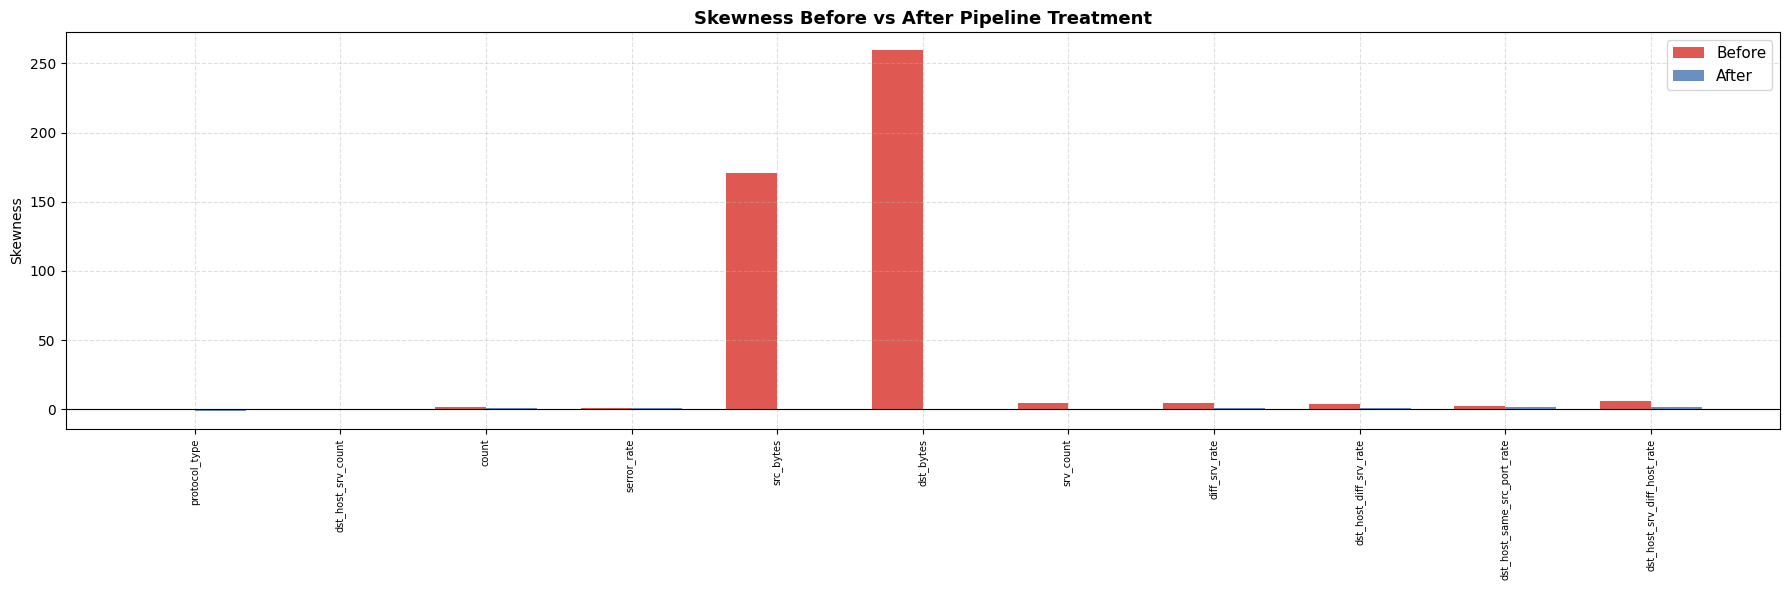

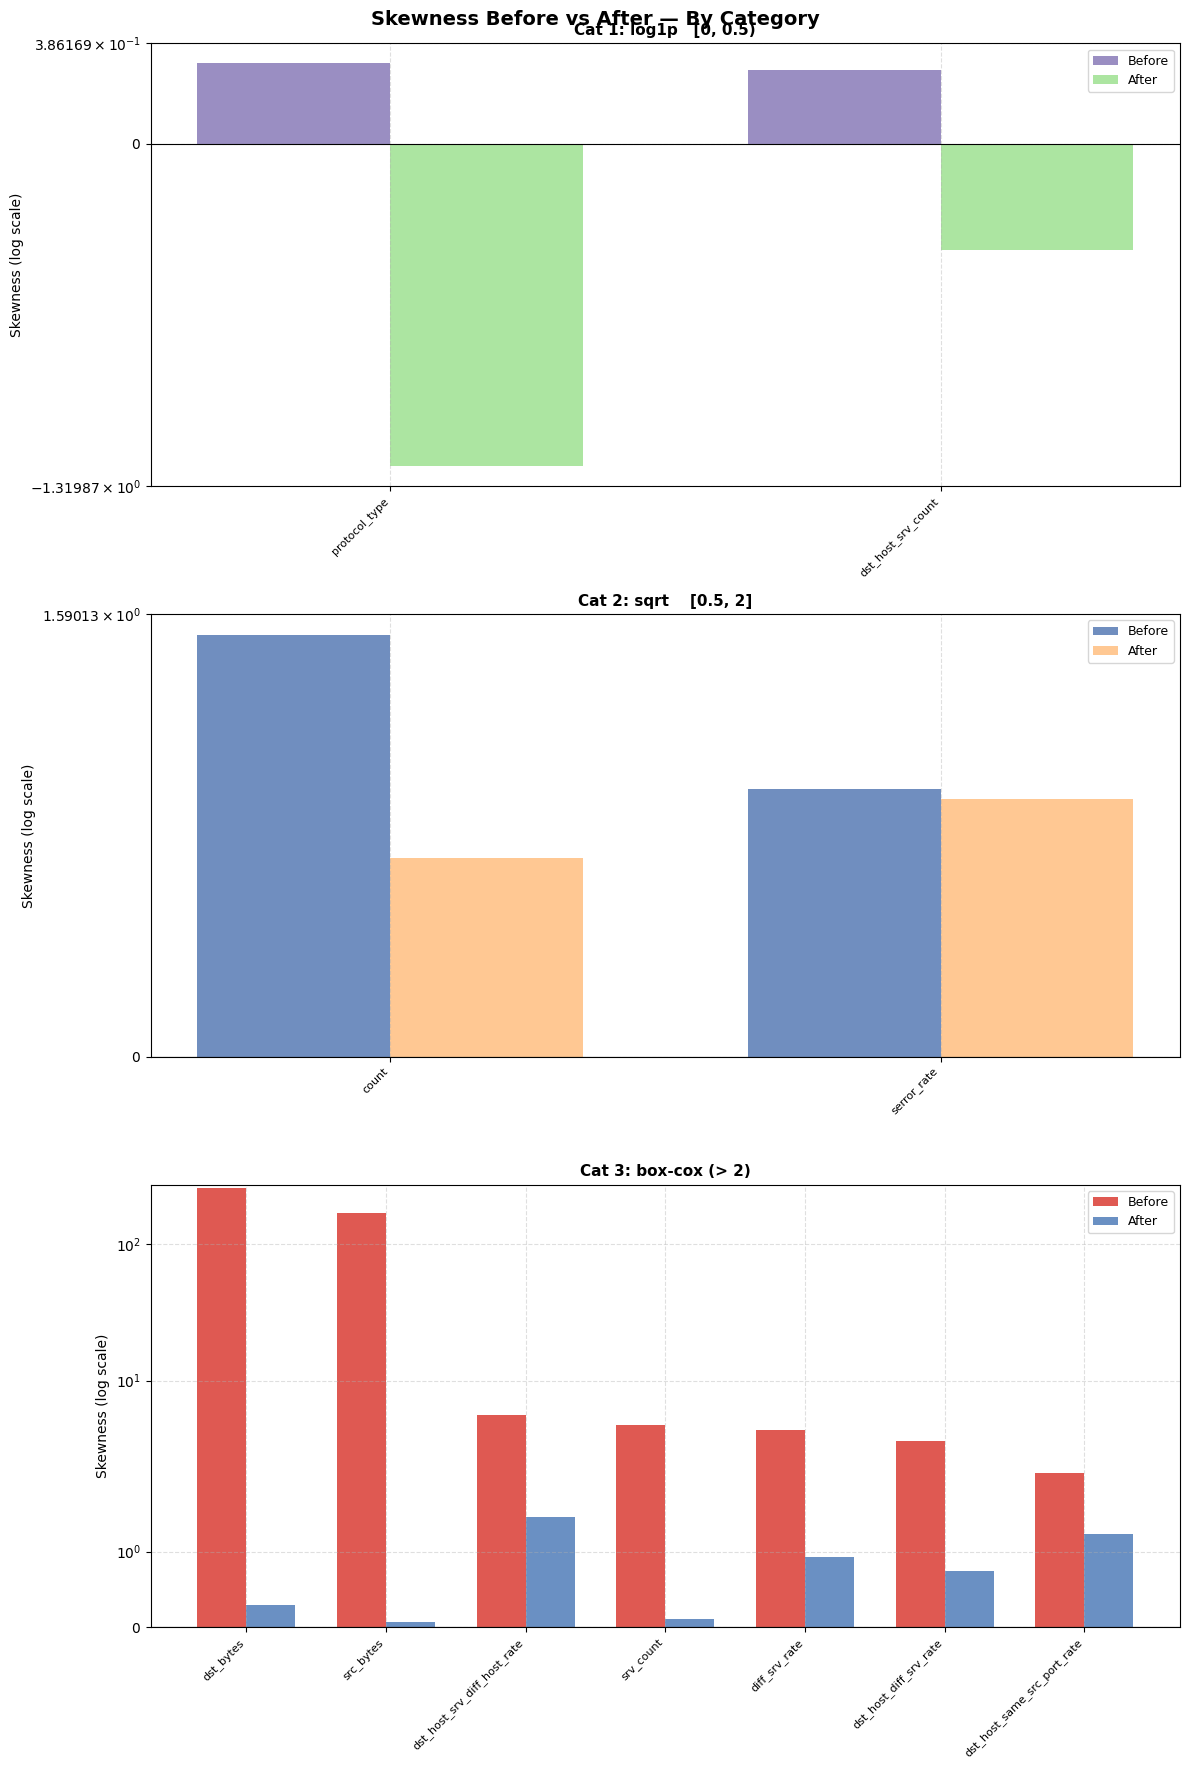

In [114]:
# ════════════════════════════════════════════════════════════════
# STEP 9: SKEWNESS BEFORE vs AFTER VISUALISATION
# ════════════════════════════════════════════════════════════════

skew_after = pd.DataFrame(
    X_train_scaled[cat1_cols + cat2_cols + cat3_cols]
).skew()

transformed_cols = cat1_cols + cat2_cols + cat3_cols

# ── Graph 1: All features combined ──
fig, ax = plt.subplots(figsize=(18, 6))
x         = np.arange(len(transformed_cols))
width     = 0.35
skew_b    = skew_train[transformed_cols]
skew_a    = skew_after.reindex(transformed_cols)

ax.bar(x - width/2, skew_b.values, width, color='#d73027', alpha=0.8, label='Before')
ax.bar(x + width/2, skew_a.values, width, color='#4575b4', alpha=0.8, label='After')
ax.set_xticks(x)
ax.set_xticklabels(transformed_cols, rotation=90, fontsize=7)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Skewness Before vs After Pipeline Treatment',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Skewness')
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('week2_skewness_before_after.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Graph 2: By category ──
fig, axes = plt.subplots(3, 1, figsize=(12, 18))
fig.suptitle('Skewness Before vs After — By Category',
             fontweight='bold', fontsize=14)

categories = [
    (cat1_cols, 'Cat 1: log1p   [0, 0.5)', '#8172b3', '#98df8a'),
    (cat2_cols, 'Cat 2: sqrt    [0.5, 2]', '#4c72b0', '#ffbb78'),
    (cat3_cols, 'Cat 3: box-cox (> 2)',    '#d73027', '#4575b4'),
]

for ax, (cols, title, c_before, c_after) in zip(axes, categories):
    skew_b = skew_train[cols].sort_values(ascending=False)
    skew_a = skew_after.reindex(skew_b.index)
    x      = np.arange(len(cols))
    width  = 0.35
    ax.bar(x - width/2, skew_b.values, width, color=c_before, alpha=0.8, label='Before')
    ax.bar(x + width/2, skew_a.values, width, color=c_after,  alpha=0.8, label='After')
    ax.set_xticks(x)
    ax.set_xticklabels(skew_b.index, rotation=45, ha='right', fontsize=8)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_yscale('symlog')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylabel('Skewness (log scale)')
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('week2_skewness_by_category.png', dpi=120, bbox_inches='tight')
plt.show()

## Understand class imbalance


── STEP 10: SMOTE on Minority Classes ──
Before SMOTE:
  DoS       : 36,741
  Normal    : 53,874
  Probe     :  9,325
  R2L       :    796
  U2R       :     42

After SMOTE:
  DoS       : 36,741
  Normal    : 53,874
  Probe     :  9,325
  R2L       :  5,000
  U2R       :  3,000


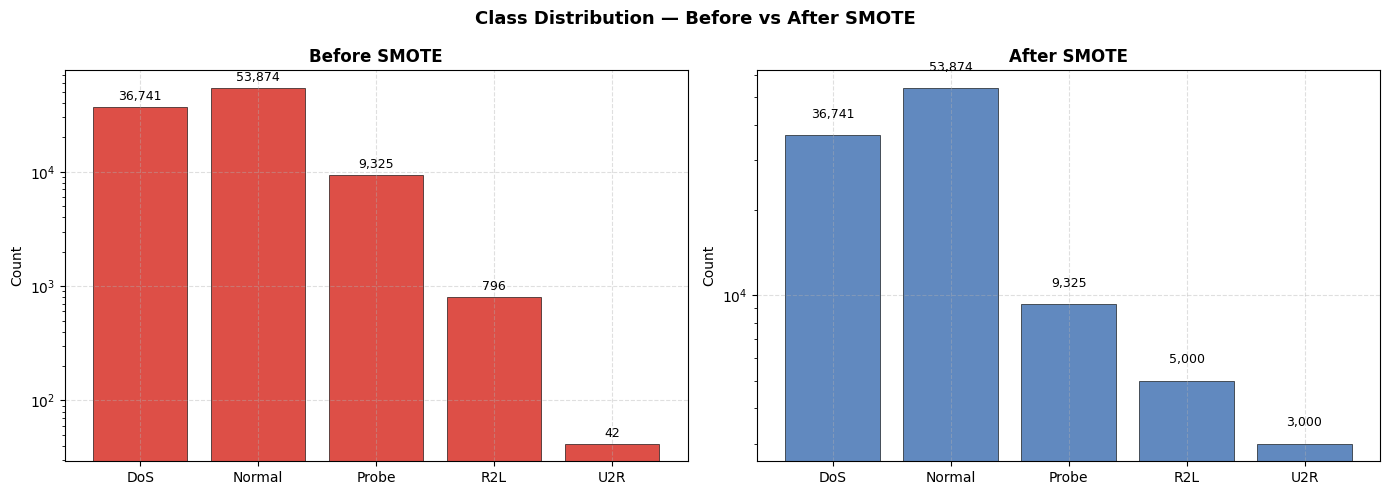

In [115]:
# ════════════════════════════════════════════════════════════════
# STEP 10: SMOTE — minority classes only
# ════════════════════════════════════════════════════════════════

from imblearn.over_sampling import SMOTE

print("\n── STEP 10: SMOTE on Minority Classes ──")

r2l_idx = list(le_multi.classes_).index('R2L')
u2r_idx = list(le_multi.classes_).index('U2R')

print("Before SMOTE:")
for i, name in enumerate(le_multi.classes_):
    n = (y_train_raw == i).sum()
    print(f"  {name:<10}: {n:6,}")

smote = SMOTE(
    sampling_strategy={r2l_idx: 5000, u2r_idx: 3000},
    random_state=42,
    k_neighbors=3
)

X_res, y_res = smote.fit_resample(
    X_train_scaled.values,
    y_train_raw
)

print("\nAfter SMOTE:")
for i, name in enumerate(le_multi.classes_):
    n = (y_res == i).sum()
    print(f"  {name:<10}: {n:6,}")

# ── Visualise SMOTE effect ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Class Distribution — Before vs After SMOTE',
             fontweight='bold', fontsize=13)

before_counts = [(y_train_raw == i).sum() for i in range(5)]
after_counts  = [(y_res == i).sum()       for i in range(5)]
x = np.arange(5)

axes[0].bar(x, before_counts, color='#d73027', alpha=0.85,
            edgecolor='black', linewidth=0.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(le_multi.classes_)
axes[0].set_title('Before SMOTE', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_yscale('log')
axes[0].grid(True, linestyle='--', alpha=0.4)
for i, val in enumerate(before_counts):
    axes[0].text(i, val * 1.15, f'{val:,}', ha='center', fontsize=9)

axes[1].bar(x, after_counts, color='#4575b4', alpha=0.85,
            edgecolor='black', linewidth=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(le_multi.classes_)
axes[1].set_title('After SMOTE', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_yscale('log')
axes[1].grid(True, linestyle='--', alpha=0.4)
for i, val in enumerate(after_counts):
    axes[1].text(i, val * 1.15, f'{val:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('week2_smote_effect.png', dpi=120, bbox_inches='tight')
plt.show()

In [116]:
# ════════════════════════════════════════════════════════════════
# WEEK 2 FINAL: PREPARE ALL VARIABLES FOR WEEK 3 AND WEEK 4
# One split was done — these variables carry forward everywhere
# No more splitting in Week 3 or Week 4
# ════════════════════════════════════════════════════════════════

# ── Binary labels from the SAME split ──
normal_idx     = list(le_multi.classes_).index('Normal')
y_train_binary = np.where(y_train_raw == normal_idx, 0, 1)
y_test_binary  = np.where(y_test_raw  == normal_idx, 0, 1)

print("="*60)
print(" ALL VARIABLES READY")
print("="*60)

print(f"\n  WEEK 3 — Binary:")
print(f"    X_train_scaled : {X_train_scaled.shape}")
print(f"    X_test_scaled  : {X_test_scaled.shape}")
print(f"    y_train_binary : {y_train_binary.shape} | Normal: {(y_train_binary==0).sum():,} | Attack: {(y_train_binary==1).sum():,}")
print(f"    y_test_binary  : {y_test_binary.shape}  | Normal: {(y_test_binary==0).sum():,}  | Attack: {(y_test_binary==1).sum():,}")

print(f"\n  WEEK 4 — Multiclass:")
print(f"    X_res          : {X_res.shape}")
print(f"    y_res          : {y_res.shape}")
print(f"    X_test_scaled  : {X_test_scaled.shape}")
print(f"    y_test_raw     : {y_test_raw.shape}")

# ── Sanity checks ──
from sklearn.tree import DecisionTreeClassifier as _DT

_dt_bin = _DT(max_depth=5, random_state=42)
_dt_bin.fit(X_train_scaled.values, y_train_binary)
bin_score = _dt_bin.score(X_test_scaled.values, y_test_binary)

_dt_multi = _DT(max_depth=5, random_state=42)
_dt_multi.fit(X_res, y_res)
multi_score = _dt_multi.score(X_test_scaled.values, y_test_raw)

print(f"\n  Sanity checks:")
print(f"    Binary    DT depth=5 : {bin_score:.4f}  {'✅' if bin_score   > 0.80 else '❌ STOP'}")
print(f"    Multiclass DT depth=5: {multi_score:.4f}  {'✅' if multi_score > 0.80 else '❌ STOP'}")


 ALL VARIABLES READY

  WEEK 3 — Binary:
    X_train_scaled : (100778, 34)
    X_test_scaled  : (25195, 34)
    y_train_binary : (100778,) | Normal: 53,874 | Attack: 46,904
    y_test_binary  : (25195,)  | Normal: 13,469  | Attack: 11,726

  WEEK 4 — Multiclass:
    X_res          : (107940, 34)
    y_res          : (107940,)
    X_test_scaled  : (25195, 34)
    y_test_raw     : (25195,)

  Sanity checks:
    Binary    DT depth=5 : 0.9871  ✅
    Multiclass DT depth=5: 0.9625  ✅


> graphs and comparisons here

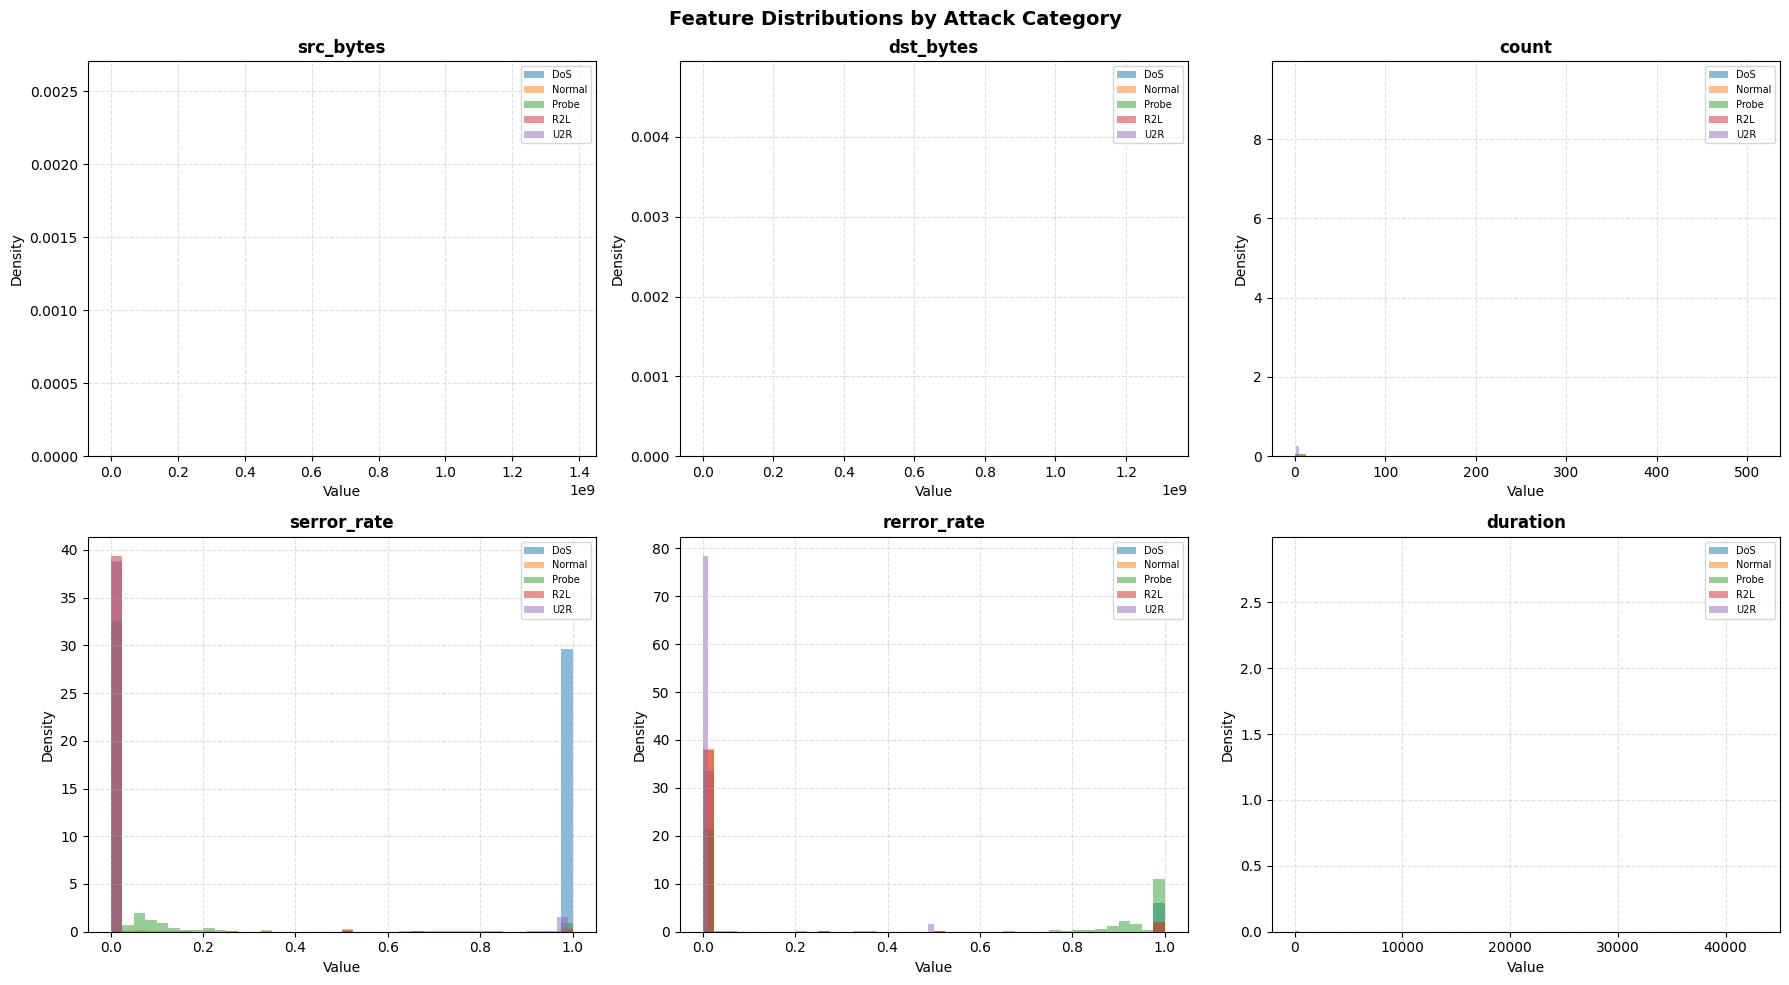

In [117]:
# ════════════════════════════════════════════════════════════════
# WEEK 2 — ADDITIONAL EDA & COMPARISON GRAPHS
# ════════════════════════════════════════════════════════════════

# ── GRAPH 1: Feature distributions by attack category ──
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Feature Distributions by Attack Category',
             fontweight='bold', fontsize=14)

key_features = ['src_bytes', 'dst_bytes', 'count',
                'serror_rate', 'rerror_rate', 'duration']

df_plot = df.copy()
df_plot['category'] = le_multi.inverse_transform(df_plot['attack_multi'])

for ax, feat in zip(axes.flatten(), key_features):
    for cat in le_multi.classes_:
        data = df_plot[df_plot['category'] == cat][feat]
        ax.hist(data, bins=40, alpha=0.5, label=cat, density=True)
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=7)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('week2_feature_distributions_by_class.png', dpi=120, bbox_inches='tight')
plt.show()

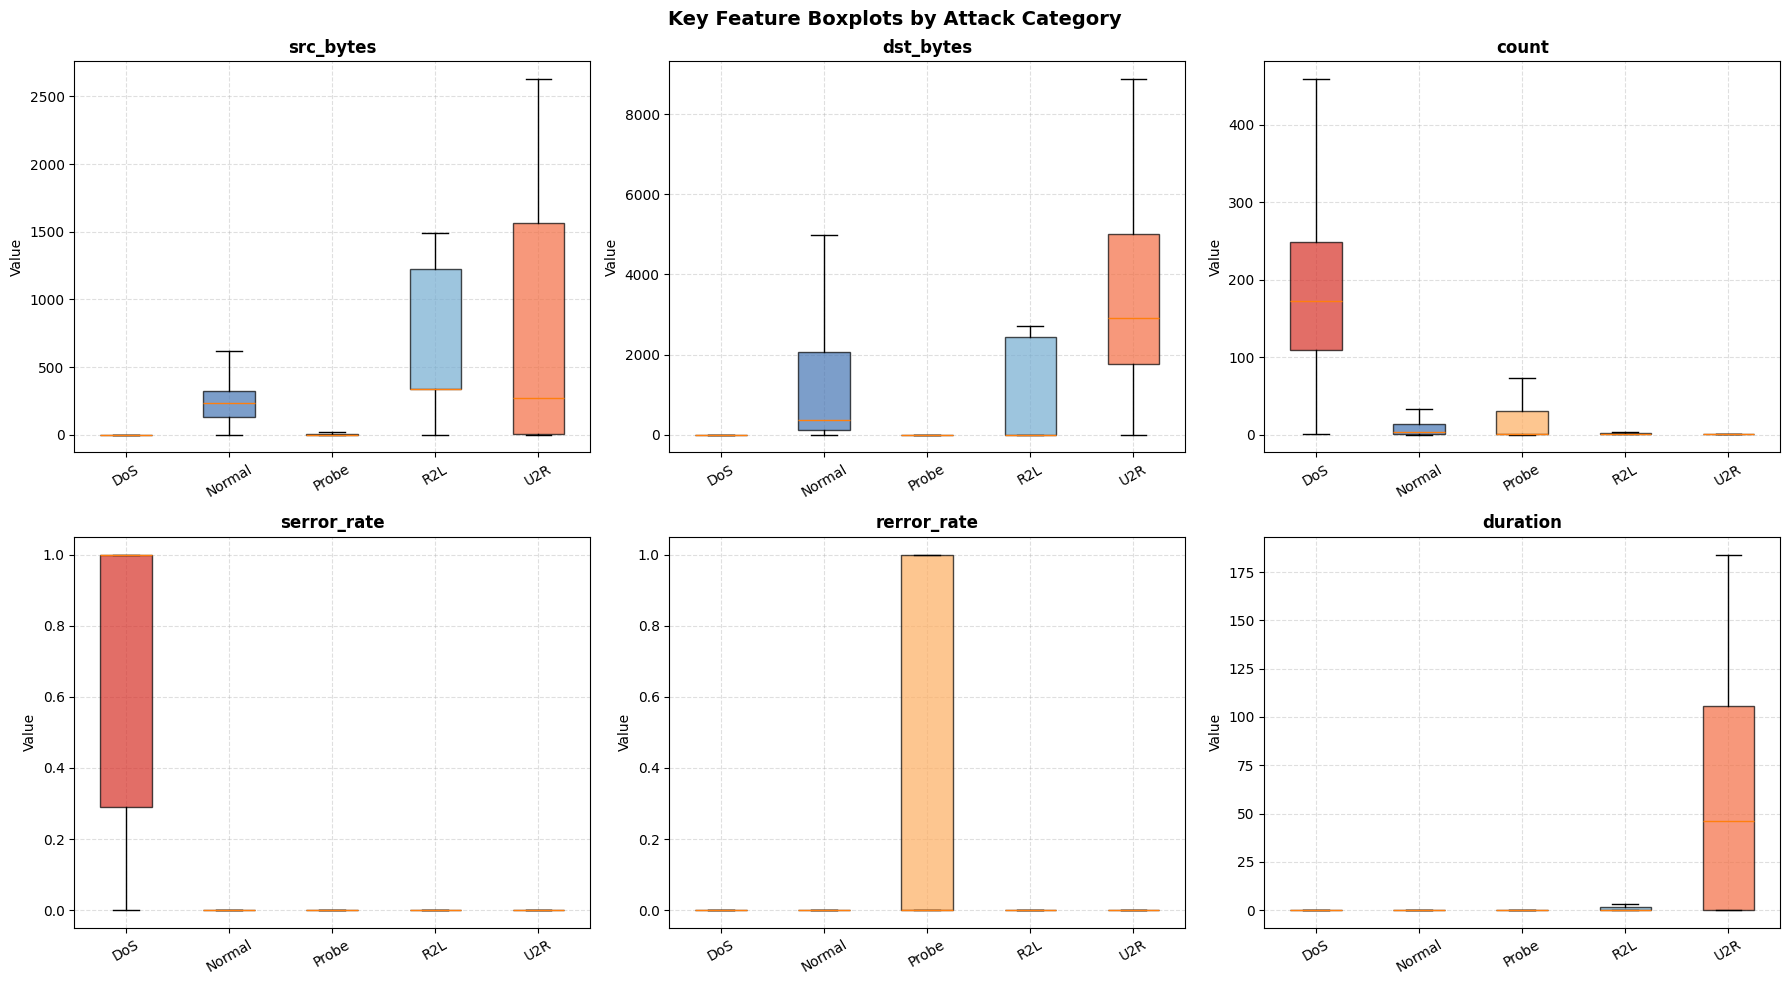

In [118]:
# ── GRAPH 2: Boxplots of key features by attack category ──
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Key Feature Boxplots by Attack Category',
             fontweight='bold', fontsize=14)

for ax, feat in zip(axes.flatten(), key_features):
    data_by_class = [df_plot[df_plot['category'] == cat][feat].values
                     for cat in le_multi.classes_]
    bp = ax.boxplot(data_by_class, patch_artist=True,
                    labels=le_multi.classes_,
                    showfliers=False)          # hide outliers for readability
    colors = ['#d73027','#4575b4','#fdae61','#74add1','#f46d43']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(feat, fontweight='bold')
    ax.set_ylabel('Value')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('week2_boxplots_by_class.png', dpi=120, bbox_inches='tight')
plt.show()

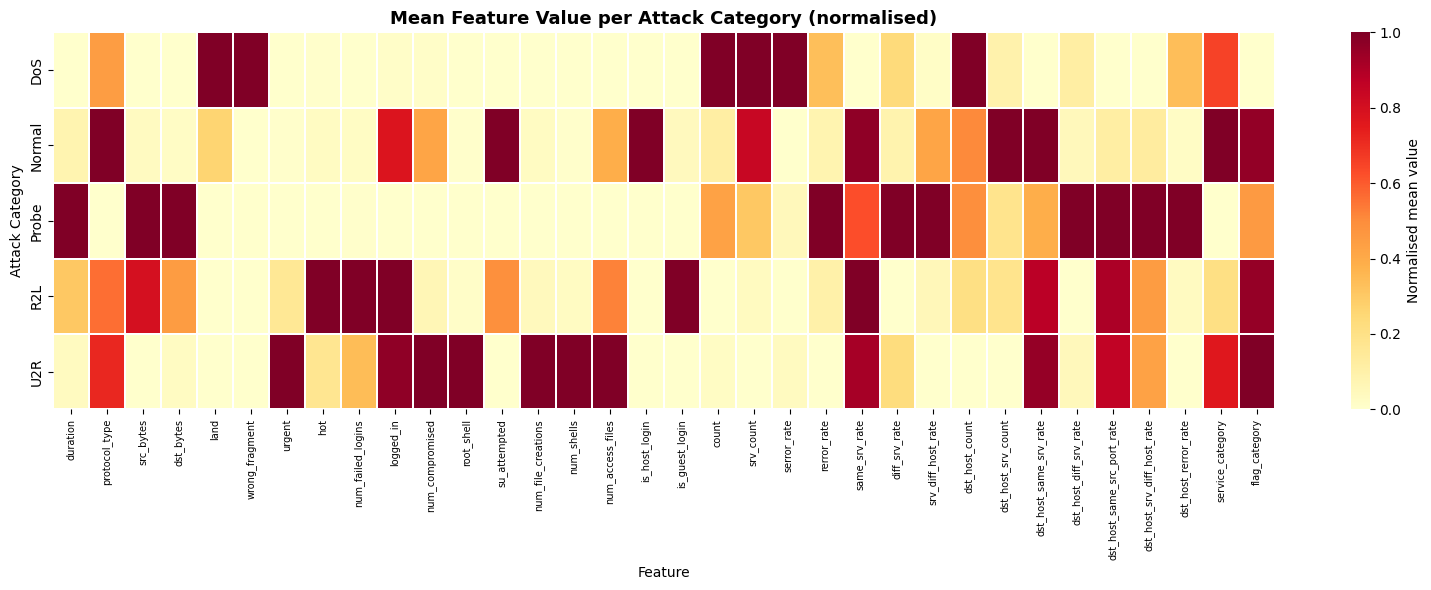

In [119]:
# ── GRAPH 3: Mean feature values — heatmap by category ──
fig, ax = plt.subplots(figsize=(16, 6))

# Use readable numerical features only
num_feats  = df_plot.select_dtypes(include='number').columns.tolist()
num_feats  = [c for c in num_feats
              if c not in ['attack_binary', 'attack_multi']]

mean_by_class = df_plot.groupby('category')[num_feats].mean()

# Normalise each column 0-1 for fair comparison
mean_norm = (mean_by_class - mean_by_class.min()) / (
             mean_by_class.max() - mean_by_class.min() + 1e-9)

sns.heatmap(mean_norm, cmap='YlOrRd', ax=ax,
            linewidths=0.3, cbar_kws={'label': 'Normalised mean value'})
ax.set_title('Mean Feature Value per Attack Category (normalised)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Feature')
ax.set_ylabel('Attack Category')
ax.tick_params(axis='x', rotation=90, labelsize=7)
plt.tight_layout()
plt.savefig('week2_mean_feature_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

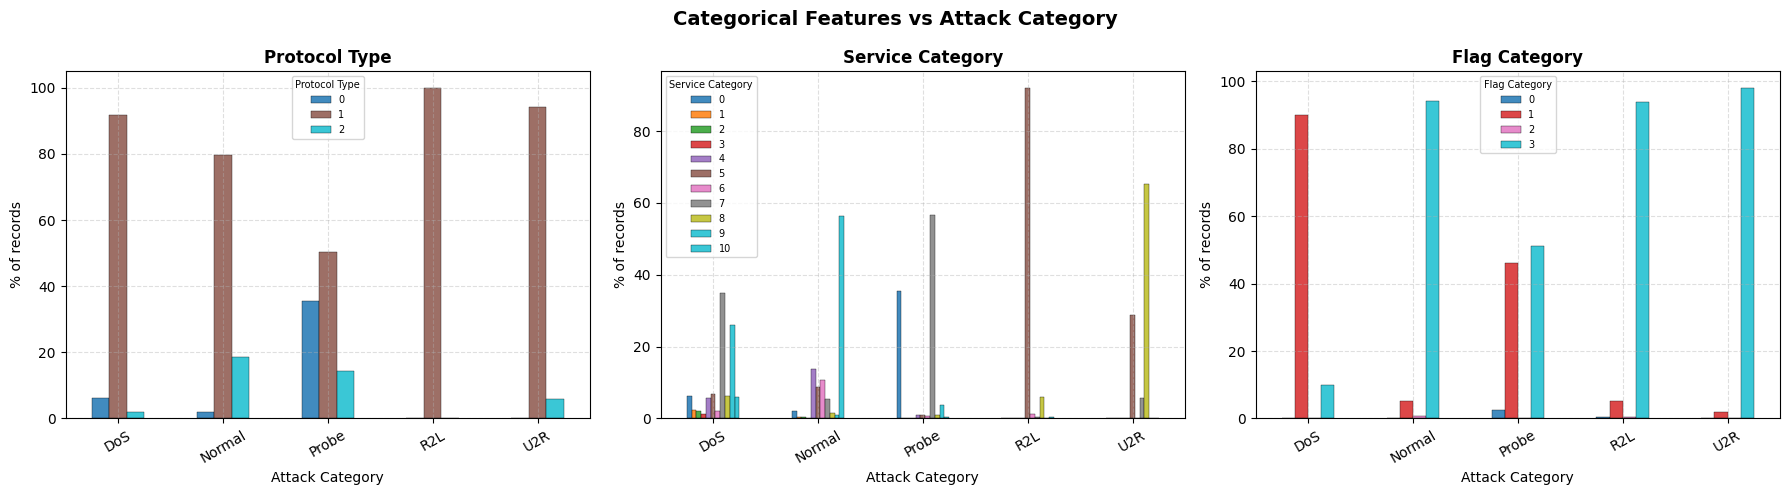

In [120]:
# ── GRAPH 4: Protocol type vs attack category ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Categorical Features vs Attack Category',
             fontweight='bold', fontsize=14)

# Decode protocol back for readability
proto_le  = LabelEncoder()
df_plot['protocol_decoded'] = proto_le.fit_transform(
    df_plot['protocol_type'].astype(str))

for ax, (feat, label) in zip(axes, [
    ('protocol_type',    'Protocol Type'),
    ('service_category', 'Service Category'),
    ('flag_category',    'Flag Category'),
]):
    ct = pd.crosstab(df_plot['category'], df_plot[feat], normalize='index') * 100
    ct.plot(kind='bar', ax=ax, colormap='tab10', alpha=0.85, edgecolor='black',
            linewidth=0.3)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Attack Category')
    ax.set_ylabel('% of records')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title=label, fontsize=7, title_fontsize=7)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('week2_categorical_vs_attack.png', dpi=120, bbox_inches='tight')
plt.show()

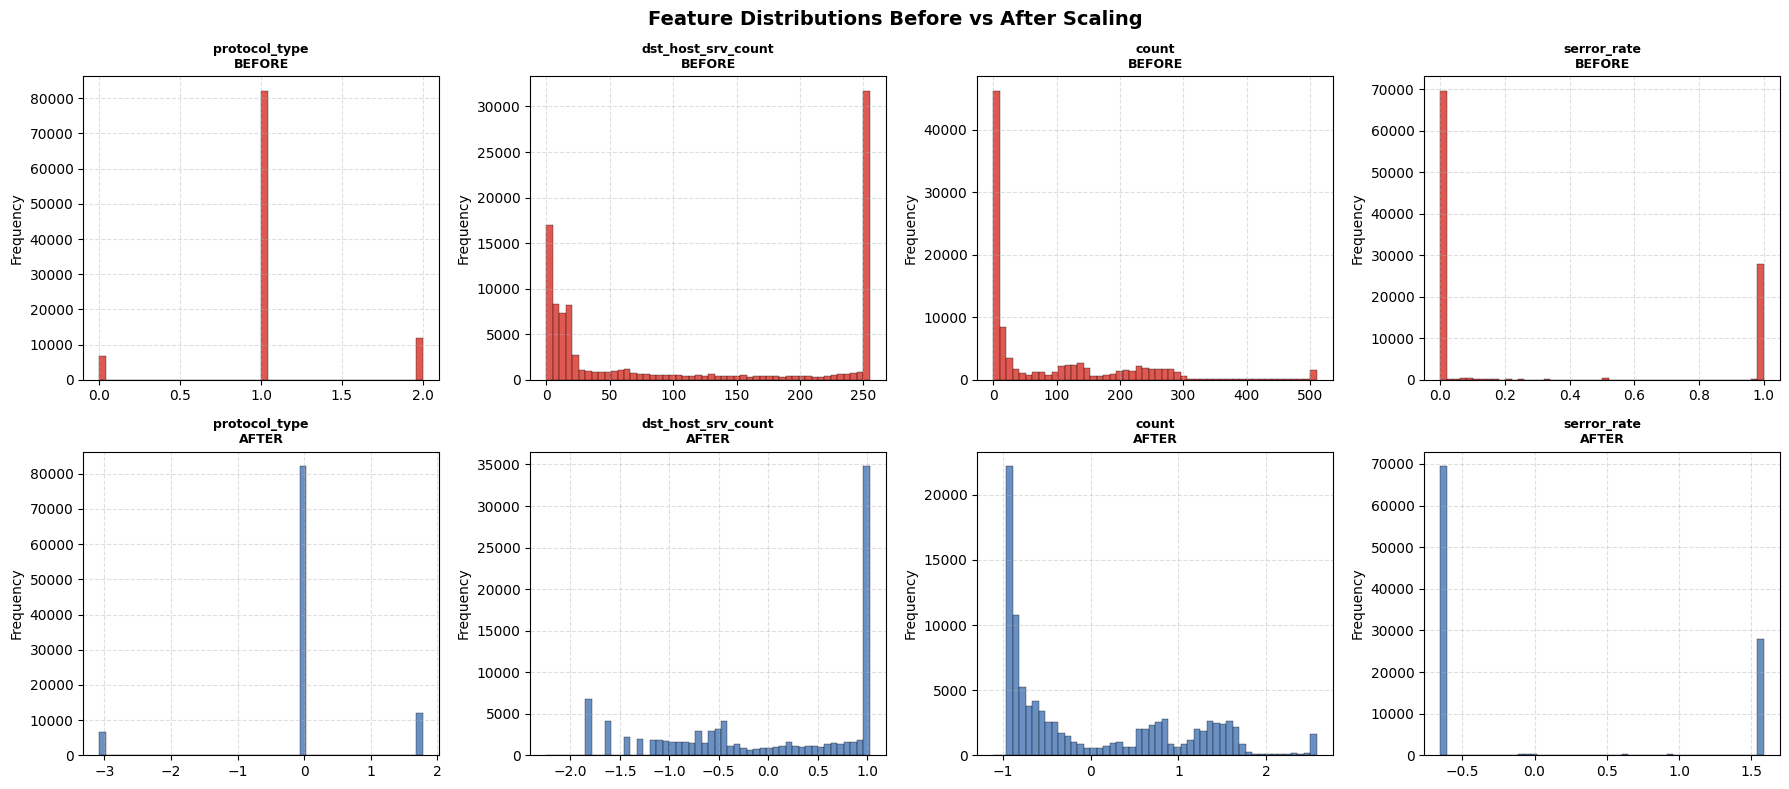

In [121]:
# ── GRAPH 5: Before vs After scaling — sample features ──
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Feature Distributions Before vs After Scaling',
             fontweight='bold', fontsize=14)

sample_feats = (cat1_cols + cat2_cols + cat3_cols)[:4]  # pick first 4 transformed

X_train_orig_df = pd.DataFrame(X_train_raw, columns=feature_names)

for i, feat in enumerate(sample_feats):
    # Before
    axes[0][i].hist(X_train_orig_df[feat].dropna(), bins=50,
                    color='#d73027', alpha=0.8, edgecolor='black', linewidth=0.3)
    axes[0][i].set_title(f'{feat}\nBEFORE', fontweight='bold', fontsize=9)
    axes[0][i].set_ylabel('Frequency')
    axes[0][i].grid(True, linestyle='--', alpha=0.4)

    # After
    axes[1][i].hist(X_train_scaled[feat].dropna(), bins=50,
                    color='#4575b4', alpha=0.8, edgecolor='black', linewidth=0.3)
    axes[1][i].set_title(f'{feat}\nAFTER', fontweight='bold', fontsize=9)
    axes[1][i].set_ylabel('Frequency')
    axes[1][i].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('week2_before_after_scaling.png', dpi=120, bbox_inches='tight')
plt.show()

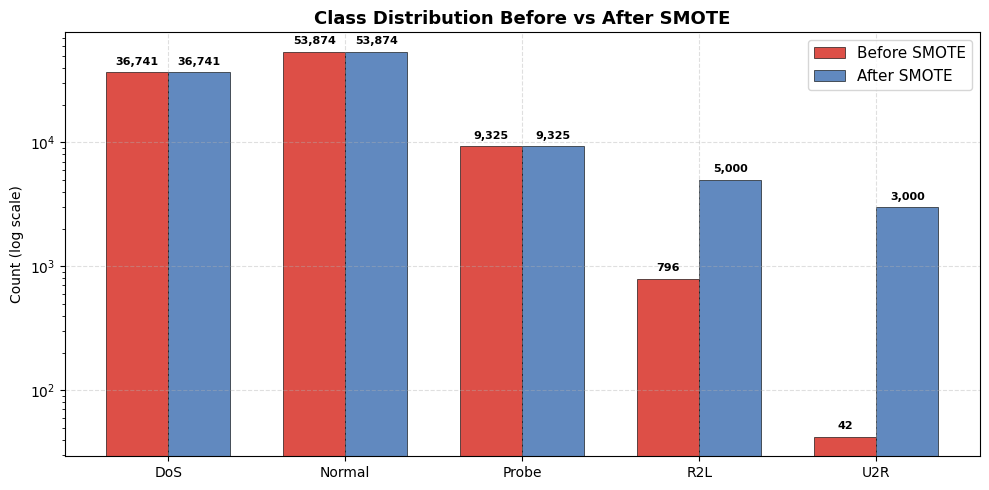

In [122]:
# ── GRAPH 6: Class imbalance ratio comparison ──
fig, ax = plt.subplots(figsize=(10, 5))

classes       = list(le_multi.classes_)
before_counts = [(y_train_raw == i).sum() for i in range(5)]
after_counts  = [(y_res == i).sum()       for i in range(5)]
x     = np.arange(5)
width = 0.35

bars1 = ax.bar(x - width/2, before_counts, width,
               color='#d73027', alpha=0.85,
               edgecolor='black', linewidth=0.5, label='Before SMOTE')
bars2 = ax.bar(x + width/2, after_counts,  width,
               color='#4575b4', alpha=0.85,
               edgecolor='black', linewidth=0.5, label='After SMOTE')

ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_yscale('log')
ax.set_title('Class Distribution Before vs After SMOTE',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Count (log scale)')
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)

for bar, val in zip(bars1, before_counts):
    ax.text(bar.get_x() + bar.get_width()/2, val * 1.15,
            f'{val:,}', ha='center', fontsize=8, fontweight='bold')
for bar, val in zip(bars2, after_counts):
    ax.text(bar.get_x() + bar.get_width()/2, val * 1.15,
            f'{val:,}', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('week2_smote_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


In [123]:
# ════════════════════════════════════════════════════════════════
# WEEK 2 SUMMARY
# ════════════════════════════════════════════════════════════════

print("\n" + "="*60)
print(" WEEK 2 COMPLETE — PREPROCESSING SUMMARY")
print("="*60)
print(f"  Constant cols dropped  : {constant_cols}")
print(f"  Redundant cols dropped : {redundant_cols}")
print(f"  Categorical encoded    : protocol_type, service_category, flag_category")
print(f"  Train set (after SMOTE): {X_res.shape}")
print(f"  Test set               : {X_test_scaled.shape}")
print(f"  Skewness treated       : {len(transformed_cols)} features")
print(f"  Scaling                : StandardScaler ")
print(f"  No data leakage        : fit on train only ")
print(f"  SMOTE applied          : R2L → 5000, U2R → 3000 ")
print(f"\n  Variables ready for Week 3:")
print(f"    X_res          : {X_res.shape}  (train features)")
print(f"    y_res          : {y_res.shape}  (train labels)")
print(f"    X_test_scaled  : {X_test_scaled.shape}  (test features)")
print(f"    y_test_raw     : {y_test_raw.shape}  (test labels)")
print(f"    le_multi       : classes = {le_multi.classes_}")


 WEEK 2 COMPLETE — PREPROCESSING SUMMARY
  Constant cols dropped  : ['num_outbound_cmds']
  Redundant cols dropped : ['num_root', 'srv_serror_rate', 'srv_rerror_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_srv_rerror_rate']
  Categorical encoded    : protocol_type, service_category, flag_category
  Train set (after SMOTE): (107940, 34)
  Test set               : (25195, 34)
  Skewness treated       : 11 features
  Scaling                : StandardScaler 
  No data leakage        : fit on train only 
  SMOTE applied          : R2L → 5000, U2R → 3000 

  Variables ready for Week 3:
    X_res          : (107940, 34)  (train features)
    y_res          : (107940,)  (train labels)
    X_test_scaled  : (25195, 34)  (test features)
    y_test_raw     : (25195,)  (test labels)
    le_multi       : classes = ['DoS' 'Normal' 'Probe' 'R2L' 'U2R']


# Baseline Models

In [124]:
print("="*60)
print(" WEEK 3: BASELINE MODELS — BINARY CLASSIFICATION")
print("="*60)

 WEEK 3: BASELINE MODELS — BINARY CLASSIFICATION


In [125]:
# Variables used — all from Week 2, no new splitting:
# X_train_scaled, y_train_binary  ← train
# X_test_scaled,  y_test_binary   ← test

X_train_w3 = X_train_scaled.values
X_test_w3  = X_test_scaled.values
y_train_w3 = y_train_binary
y_test_w3  = y_test_binary

print(f"  X_train : {X_train_w3.shape}")
print(f"  X_test  : {X_test_w3.shape}")
print(f"  y_train : Normal={( y_train_w3==0).sum():,} | Attack={(y_train_w3==1).sum():,}")
print(f"  y_test  : Normal={(y_test_w3==0).sum():,} | Attack={(y_test_w3==1).sum():,}")

  X_train : (100778, 34)
  X_test  : (25195, 34)
  y_train : Normal=53,874 | Attack=46,904
  y_test  : Normal=13,469 | Attack=11,726


In [127]:
# ════════════════════════════════════════════════════════════════
# STEP 1: BASELINE MODELS — DEFAULT PARAMETERS
# ════════════════════════════════════════════════════════════════

print("\n── STEP 1: Baseline Models (default parameters) ──")

models_w3 = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'KNN'                : KNeighborsClassifier()
}

baseline_results_w3 = {}

for name, model in models_w3.items():
    model.fit(X_train_w3, y_train_w3)

    y_pred_train = model.predict(X_train_w3)
    y_pred_test  = model.predict(X_test_w3)

    train_acc = accuracy_score(y_train_w3, y_pred_train)
    test_acc  = accuracy_score(y_test_w3,  y_pred_test)
    train_f1  = f1_score(y_train_w3, y_pred_train, average='weighted')
    test_f1   = f1_score(y_test_w3,  y_pred_test,  average='weighted')
    cv_scores = cross_val_score(model, X_train_w3, y_train_w3,
                                cv=5, scoring='f1_weighted', n_jobs=-1)

    baseline_results_w3[name] = {
        'model'      : model,
        'y_pred_train': y_pred_train,
        'y_pred_test' : y_pred_test,
        'train_acc'  : train_acc,
        'test_acc'   : test_acc,
        'train_f1'   : train_f1,
        'test_f1'    : test_f1,
        'cv_mean'    : cv_scores.mean(),
        'cv_std'     : cv_scores.std(),
        'gap'        : train_acc - test_acc,
    }

    print(f"\n  {name}")
    print(f"    Train Accuracy : {train_acc:.4f}")
    print(f"    Test  Accuracy : {test_acc:.4f}")
    print(f"    Train F1       : {train_f1:.4f}")
    print(f"    Test  F1       : {test_f1:.4f}")
    print(f"    CV F1          : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"    Gap            : {train_acc - test_acc:.4f}  "
          f"{' overfitting' if train_acc - test_acc > 0.05 else 'generalising well'}")


── STEP 1: Baseline Models (default parameters) ──

  Logistic Regression
    Train Accuracy : 0.9571
    Test  Accuracy : 0.9563
    Train F1       : 0.9571
    Test  F1       : 0.9563
    CV F1          : 0.9568 ± 0.0017
    Gap            : 0.0007  generalising well

  Decision Tree
    Train Accuracy : 1.0000
    Test  Accuracy : 0.9981
    Train F1       : 1.0000
    Test  F1       : 0.9981
    CV F1          : 0.9978 ± 0.0003
    Gap            : 0.0018  generalising well

  KNN
    Train Accuracy : 0.9980
    Test  Accuracy : 0.9963
    Train F1       : 0.9980
    Test  F1       : 0.9963
    CV F1          : 0.9966 ± 0.0005
    Gap            : 0.0017  generalising well


In [128]:
# ════════════════════════════════════════════════════════════════
# STEP 2: CLASSIFICATION REPORTS
# ════════════════════════════════════════════════════════════════

print("\n── STEP 2: Classification Reports ──")

for name, res in baseline_results_w3.items():
    print(f"\n{'='*55}")
    print(f" {name}")
    print(f"{'='*55}")
    print(classification_report(
        y_test_w3, res['y_pred_test'],
        target_names=['Normal', 'Attack']
    ))


── STEP 2: Classification Reports ──

 Logistic Regression
              precision    recall  f1-score   support

      Normal       0.95      0.97      0.96     13469
      Attack       0.96      0.95      0.95     11726

    accuracy                           0.96     25195
   macro avg       0.96      0.96      0.96     25195
weighted avg       0.96      0.96      0.96     25195


 Decision Tree
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     13469
      Attack       1.00      1.00      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195


 KNN
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     13469
      Attack       1.00      1.00      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00   


── STEP 3: Confusion Matrices ──


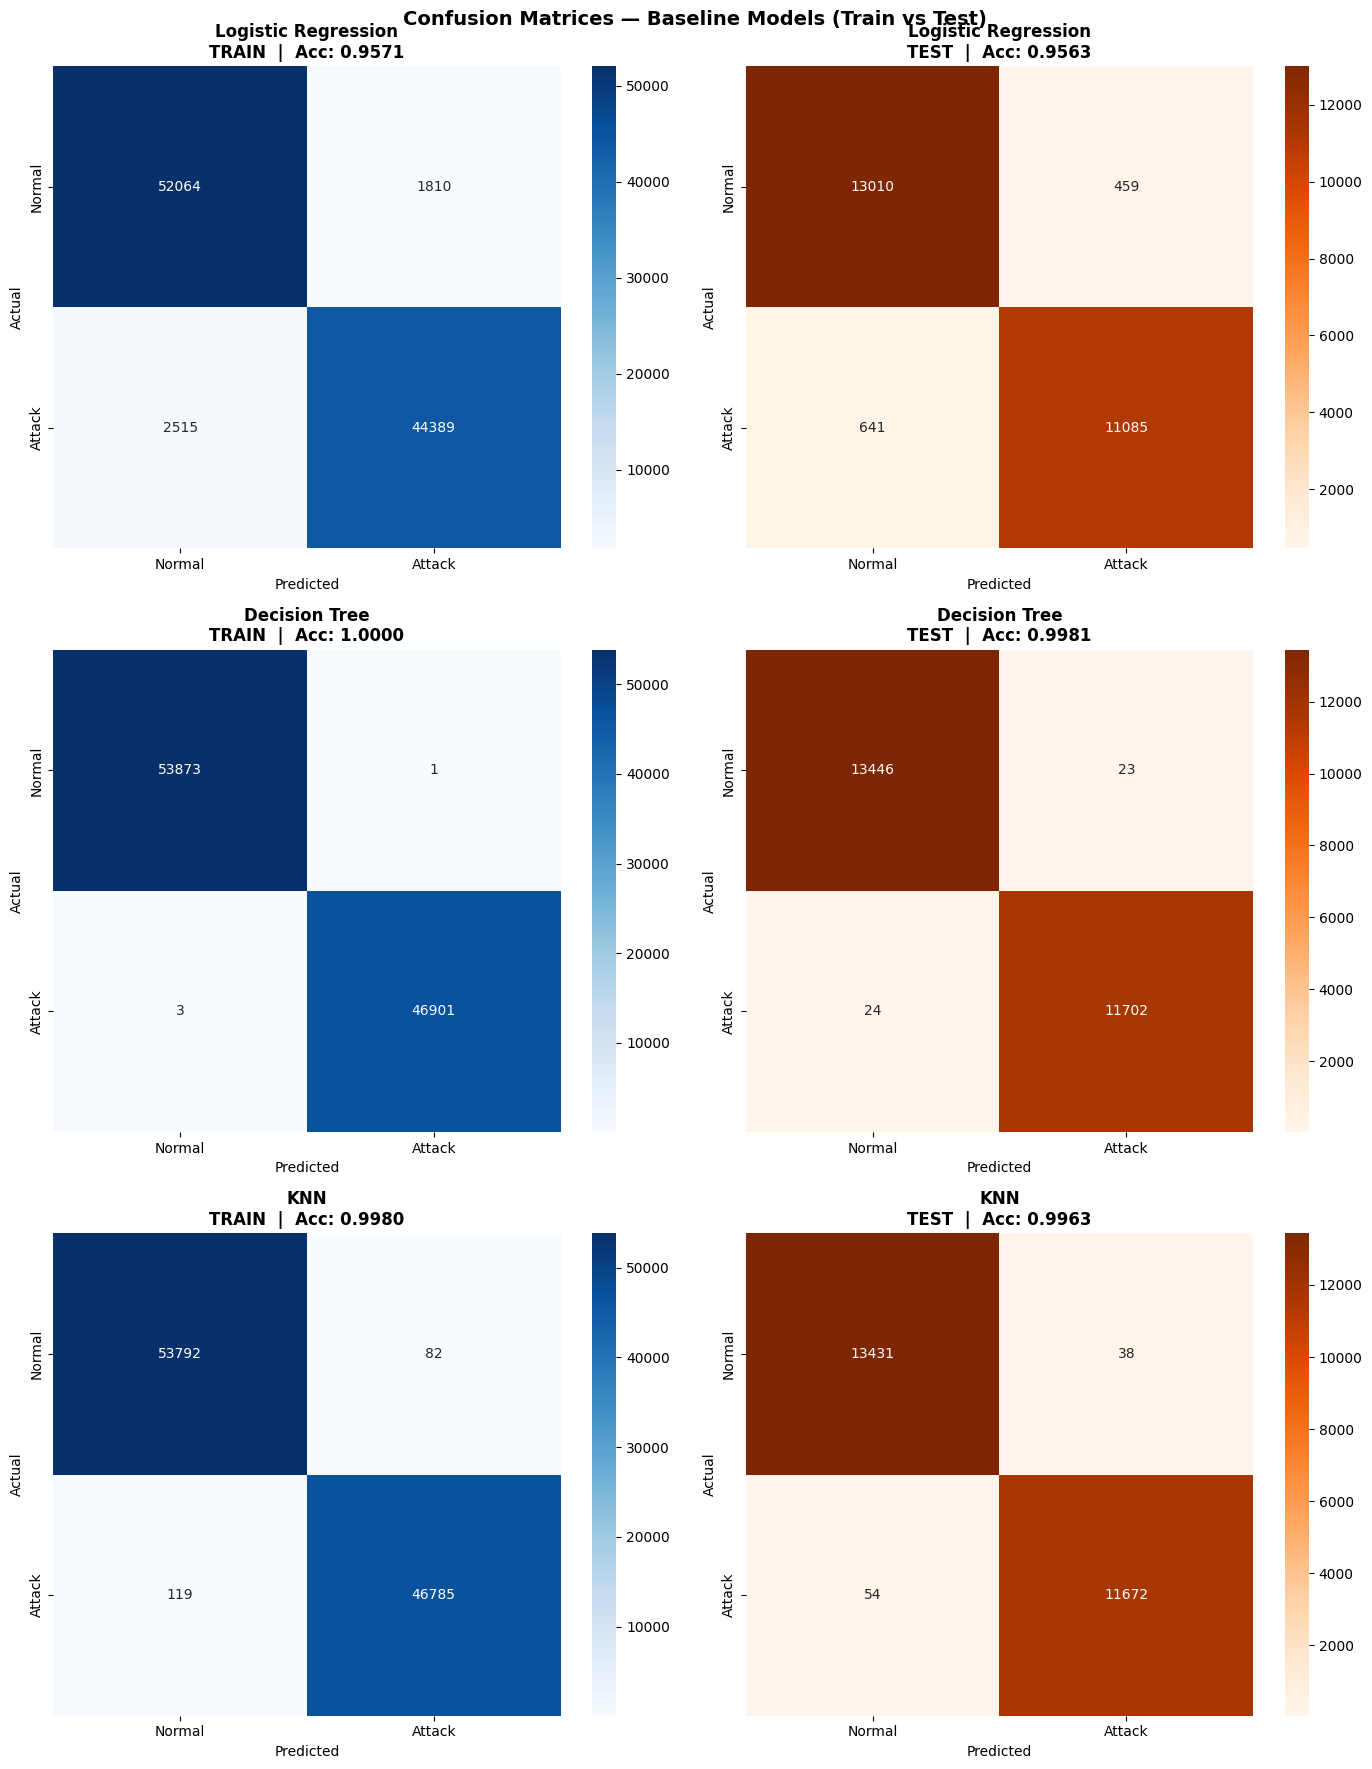

In [129]:
# ════════════════════════════════════════════════════════════════
# STEP 3: CONFUSION MATRICES — TRAIN AND TEST SIDE BY SIDE
# ════════════════════════════════════════════════════════════════

print("\n── STEP 3: Confusion Matrices ──")

fig, axes = plt.subplots(3, 2, figsize=(14, 18))
fig.suptitle('Confusion Matrices — Baseline Models (Train vs Test)',
             fontweight='bold', fontsize=14)

for row, (name, res) in enumerate(baseline_results_w3.items()):
    # Train
    cm_train = confusion_matrix(y_train_w3, res['y_pred_train'])
    sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Attack'],
                yticklabels=['Normal', 'Attack'],
                ax=axes[row][0])
    axes[row][0].set_title(
        f"{name}\nTRAIN  |  Acc: {res['train_acc']:.4f}",
        fontweight='bold')
    axes[row][0].set_xlabel('Predicted')
    axes[row][0].set_ylabel('Actual')

    # Test
    cm_test = confusion_matrix(y_test_w3, res['y_pred_test'])
    sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges',
                xticklabels=['Normal', 'Attack'],
                yticklabels=['Normal', 'Attack'],
                ax=axes[row][1])
    axes[row][1].set_title(
        f"{name}\nTEST  |  Acc: {res['test_acc']:.4f}",
        fontweight='bold')
    axes[row][1].set_xlabel('Predicted')
    axes[row][1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('week3_confusion_baseline.png', dpi=120, bbox_inches='tight')
plt.show()

In [130]:
# ════════════════════════════════════════════════════════════════
# STEP 4: HYPERPARAMETER TUNING
# ════════════════════════════════════════════════════════════════

print("\n── STEP 4: Hyperparameter Tuning (GridSearchCV) ──")

# ── Logistic Regression ──
print("\n  Tuning Logistic Regression...")
lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    {'C'     : [0.01, 0.1, 1, 10, 100],
     'solver': ['lbfgs', 'liblinear']},
    cv=5, scoring='f1_weighted', n_jobs=-1
)
lr_grid.fit(X_train_w3, y_train_w3)
print(f"    Best params : {lr_grid.best_params_}")
print(f"    Best CV F1  : {lr_grid.best_score_:.4f}")

# ── Decision Tree ──
print("\n  Tuning Decision Tree...")
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    {'max_depth'        : [3, 5, 10, 15, 20, None],
     'min_samples_split': [2, 5, 10],
     'criterion'        : ['gini', 'entropy']},
    cv=5, scoring='f1_weighted', n_jobs=-1
)
dt_grid.fit(X_train_w3, y_train_w3)
print(f"    Best params : {dt_grid.best_params_}")
print(f"    Best CV F1  : {dt_grid.best_score_:.4f}")

# ── KNN ──
print("\n  Tuning KNN...")
knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    {'n_neighbors': [3, 5, 7, 11, 15],
     'weights'    : ['uniform', 'distance'],
     'metric'     : ['euclidean', 'manhattan']},
    cv=5, scoring='f1_weighted', n_jobs=-1
)
knn_grid.fit(X_train_w3, y_train_w3)
print(f"    Best params : {knn_grid.best_params_}")
print(f"    Best CV F1  : {knn_grid.best_score_:.4f}")


── STEP 4: Hyperparameter Tuning (GridSearchCV) ──

  Tuning Logistic Regression...
    Best params : {'C': 100, 'solver': 'lbfgs'}
    Best CV F1  : 0.9572

  Tuning Decision Tree...
    Best params : {'criterion': 'entropy', 'max_depth': 15, 'min_samples_split': 5}
    Best CV F1  : 0.9980

  Tuning KNN...
    Best params : {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
    Best CV F1  : 0.9980


In [131]:
# ════════════════════════════════════════════════════════════════
# STEP 5: EVALUATE TUNED MODELS
# ════════════════════════════════════════════════════════════════

print("\n── STEP 5: Tuned Model Evaluation ──")

tuned_models_w3 = {
    'Logistic Regression': lr_grid.best_estimator_,
    'Decision Tree'      : dt_grid.best_estimator_,
    'KNN'                : knn_grid.best_estimator_,
}

tuned_results_w3 = {}

for name, model in tuned_models_w3.items():
    y_pred_train = model.predict(X_train_w3)
    y_pred_test  = model.predict(X_test_w3)

    train_acc = accuracy_score(y_train_w3, y_pred_train)
    test_acc  = accuracy_score(y_test_w3,  y_pred_test)
    train_f1  = f1_score(y_train_w3, y_pred_train, average='weighted')
    test_f1   = f1_score(y_test_w3,  y_pred_test,  average='weighted')

    tuned_results_w3[name] = {
        'model'      : model,
        'y_pred_train': y_pred_train,
        'y_pred_test' : y_pred_test,
        'train_acc'  : train_acc,
        'test_acc'   : test_acc,
        'train_f1'   : train_f1,
        'test_f1'    : test_f1,
        'gap'        : train_acc - test_acc,
    }

    print(f"\n  {name} (tuned)")
    print(f"    Train Accuracy : {train_acc:.4f}")
    print(f"    Test  Accuracy : {test_acc:.4f}")
    print(f"    Train F1       : {train_f1:.4f}")
    print(f"    Test  F1       : {test_f1:.4f}")
    print(f"    Gap            : {train_acc - test_acc:.4f}  "
          f"{' overfitting' if train_acc - test_acc > 0.05 else ' generalising well'}")
    print(classification_report(
        y_test_w3, y_pred_test,
        target_names=['Normal', 'Attack']
    ))


── STEP 5: Tuned Model Evaluation ──

  Logistic Regression (tuned)
    Train Accuracy : 0.9572
    Test  Accuracy : 0.9565
    Train F1       : 0.9572
    Test  F1       : 0.9565
    Gap            : 0.0006   generalising well
              precision    recall  f1-score   support

      Normal       0.95      0.97      0.96     13469
      Attack       0.96      0.95      0.95     11726

    accuracy                           0.96     25195
   macro avg       0.96      0.96      0.96     25195
weighted avg       0.96      0.96      0.96     25195


  Decision Tree (tuned)
    Train Accuracy : 0.9998
    Test  Accuracy : 0.9979
    Train F1       : 0.9998
    Test  F1       : 0.9979
    Gap            : 0.0018   generalising well
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     13469
      Attack       1.00      1.00      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.

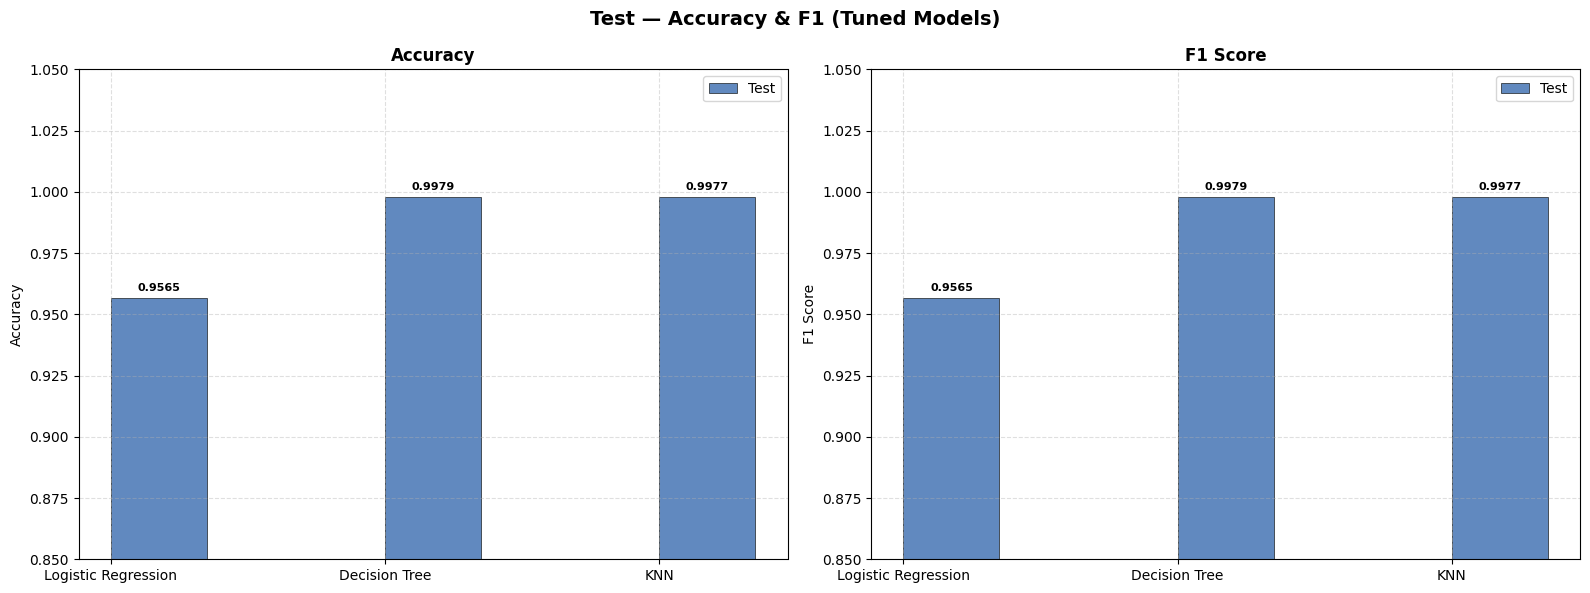

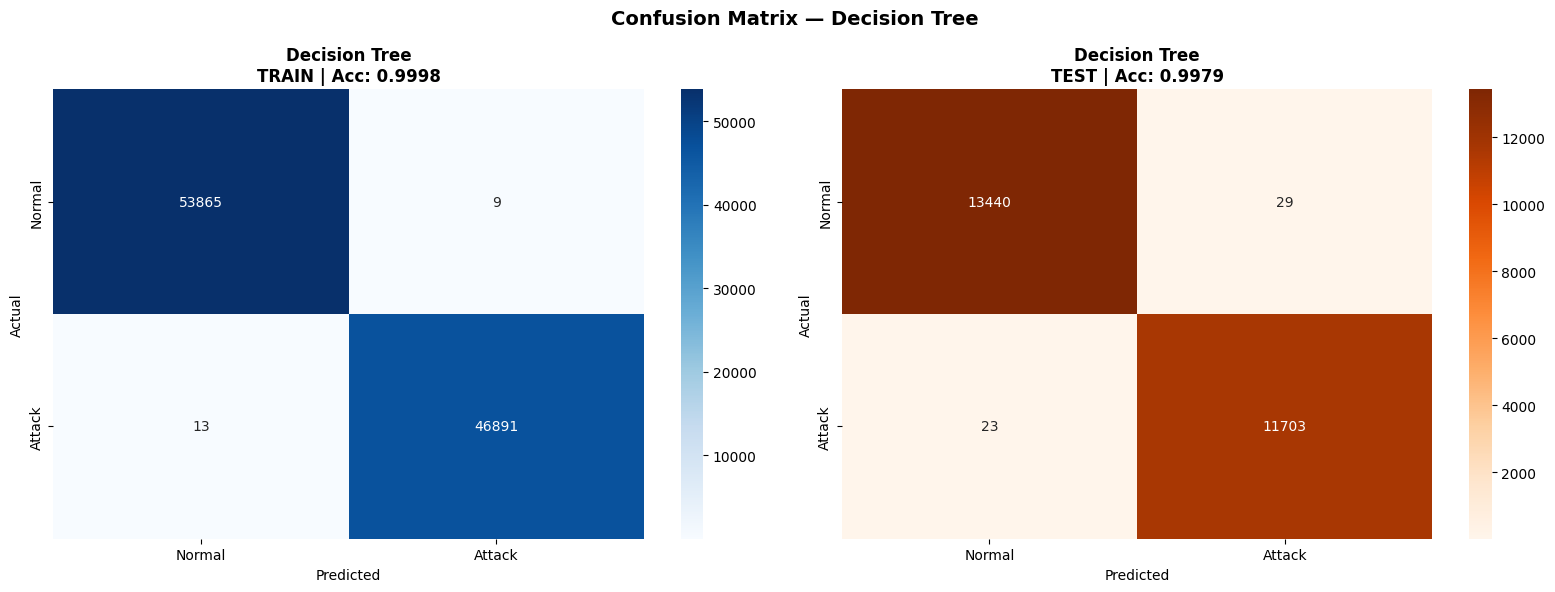

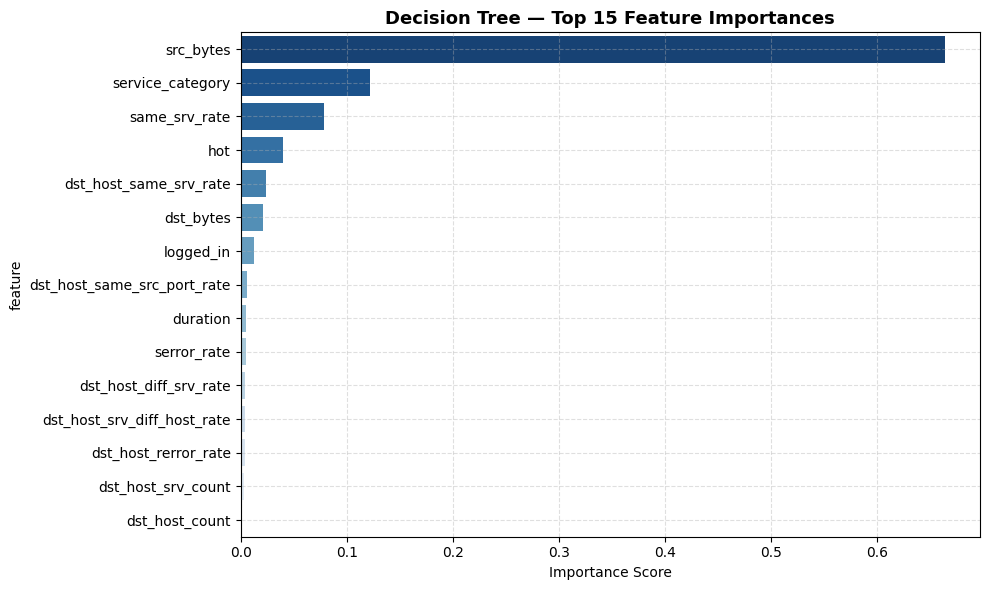

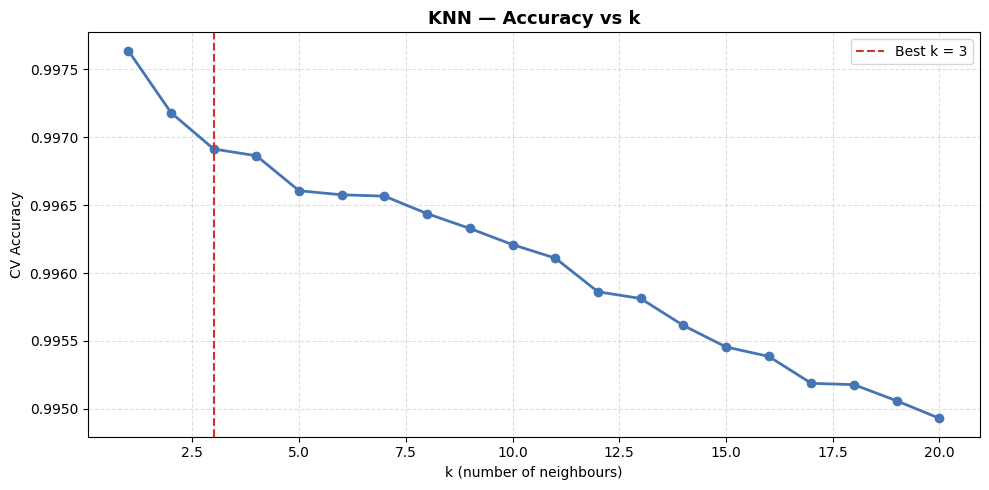

In [132]:
# ════════════════════════════════════════════════════════════════
# STEP 6: COMPARISON GRAPHS
# ════════════════════════════════════════════════════════════════

names_w3  = list(tuned_results_w3.keys())
train_acc = [tuned_results_w3[n]['train_acc'] for n in names_w3]
test_acc  = [tuned_results_w3[n]['test_acc']  for n in names_w3]
train_f1  = [tuned_results_w3[n]['train_f1']  for n in names_w3]
test_f1   = [tuned_results_w3[n]['test_f1']   for n in names_w3]
gaps      = [tuned_results_w3[n]['gap']        for n in names_w3]
cv_means  = [baseline_results_w3[n]['cv_mean'] for n in names_w3]
cv_stds   = [baseline_results_w3[n]['cv_std']  for n in names_w3]

x     = np.arange(len(names_w3))
width = 0.35

#  Test Accuracy and F1 ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Test — Accuracy & F1 (Tuned Models)',
             fontweight='bold', fontsize=14)

for ax, (te_vals, metric) in zip(axes, [
    (test_acc, 'Accuracy'),
    (test_f1,  'F1 Score'),
]):
    ax.bar(x + width/2, te_vals, width, color='#4575b4',
           alpha=0.85, label='Test',  edgecolor='black', linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(names_w3)
    ax.set_ylim(0.85, 1.05)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylabel(metric)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.4)
    for i,  te in enumerate( te_vals):
        ax.text(i + width/2, te + 0.003, f'{te:.4f}',
                ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('week3_test.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Graph 5: Confusion matrices tuned ──

# Extract Decision Tree results directly
dt_res = tuned_results_w3['Decision Tree']

# Set up a single row with 2 subplots (Train vs Test)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Confusion Matrix — Decision Tree', fontweight='bold', fontsize=14)

# 1. Train Confusion Matrix
cm_train = confusion_matrix(y_train_w3, dt_res['y_pred_train'])
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'],
            ax=axes[0])
axes[0].set_title(f"Decision Tree\nTRAIN | Acc: {dt_res['train_acc']:.4f}", fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# 2. Test Confusion Matrix
cm_test = confusion_matrix(y_test_w3, dt_res['y_pred_test'])
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'],
            ax=axes[1])
axes[1].set_title(f"Decision Tree\nTEST | Acc: {dt_res['test_acc']:.4f}", fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# ── Graph 6: Decision Tree feature importance ──
feat_df = pd.DataFrame({
    'feature'   : X_train_scaled.columns.tolist(),
    'importance': dt_grid.best_estimator_.feature_importances_
}).sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=feat_df, x='importance', y='feature',
            palette='Blues_r', ax=ax)
ax.set_title('Decision Tree — Top 15 Feature Importances',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Importance Score')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('week3_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Graph 7: KNN k vs accuracy ──
k_range  = range(1, 21)
k_scores = [cross_val_score(
                KNeighborsClassifier(n_neighbors=k),
                X_train_w3, y_train_w3,
                cv=5, scoring='accuracy', n_jobs=-1
            ).mean() for k in k_range]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_range, k_scores, marker='o', color='#4575b4',
        linewidth=2, markersize=6)
ax.axvline(x=knn_grid.best_params_['n_neighbors'],
           color='#d73027', linestyle='--', linewidth=1.5,
           label=f"Best k = {knn_grid.best_params_['n_neighbors']}")
ax.set_title('KNN — Accuracy vs k', fontweight='bold', fontsize=13)
ax.set_xlabel('k (number of neighbours)')
ax.set_ylabel('CV Accuracy')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('week3_knn_k_accuracy.png', dpi=120, bbox_inches='tight')
plt.show()

In [134]:
# ════════════════════════════════════════════════════════════════
# STEP 7: WEEK 3 SUMMARY
# ════════════════════════════════════════════════════════════════

print("\n" + "="*60)
print(" WEEK 3 SUMMARY — BINARY CLASSIFICATION")
print("="*60)

summary_w3 = pd.DataFrame({
    'Model'     : names_w3,
    'Train Acc' : [round(tuned_results_w3[n]['train_acc'], 4) for n in names_w3],
    'Test Acc'  : [round(tuned_results_w3[n]['test_acc'],  4) for n in names_w3],
    'Train F1'  : [round(tuned_results_w3[n]['train_f1'],  4) for n in names_w3],
    'Test F1'   : [round(tuned_results_w3[n]['test_f1'],   4) for n in names_w3],
    'Gap'       : [round(tuned_results_w3[n]['gap'],        4) for n in names_w3],
    'CV F1'     : [round(baseline_results_w3[n]['cv_mean'], 4) for n in names_w3],
})
print(summary_w3.to_string(index=False))

best_w3 = max(tuned_results_w3, key=lambda n: tuned_results_w3[n]['test_f1'])
print(f"\n Best model for Binary Classification : {best_w3}")
print(f"   Test Accuracy : {tuned_results_w3[best_w3]['test_acc']:.4f}")
print(f"   Test F1 Score : {tuned_results_w3[best_w3]['test_f1']:.4f}")



 WEEK 3 SUMMARY — BINARY CLASSIFICATION
              Model  Train Acc  Test Acc  Train F1  Test F1    Gap  CV F1
Logistic Regression     0.9572    0.9565    0.9572   0.9565 0.0006 0.9568
      Decision Tree     0.9998    0.9979    0.9998   0.9979 0.0018 0.9978
                KNN     1.0000    0.9977    1.0000   0.9977 0.0023 0.9966

 Best model for Binary Classification : Decision Tree
   Test Accuracy : 0.9979
   Test F1 Score : 0.9979


# Advanced Models

In [135]:
print("="*60)
print(" WEEK 4: ADVANCED MODELS — MULTICLASS CLASSIFICATION")
print("="*60)

 WEEK 4: ADVANCED MODELS — MULTICLASS CLASSIFICATION


In [136]:
X_train_w4 = X_res
y_train_w4 = y_res
X_test_w4  = X_test_scaled.values
y_test_w4  = y_test_raw

print(f"  X_train : {X_train_w4.shape}")
print(f"  X_test  : {X_test_w4.shape}")
print(f"\n  Train class distribution (after SMOTE):")
for i, name in enumerate(le_multi.classes_):
    print(f"    {name:<10}: {(y_train_w4==i).sum():,}")
print(f"\n  Test class distribution:")
for i, name in enumerate(le_multi.classes_):
    print(f"    {name:<10}: {(y_test_w4==i).sum():,}")

  X_train : (107940, 34)
  X_test  : (25195, 34)

  Train class distribution (after SMOTE):
    DoS       : 36,741
    Normal    : 53,874
    Probe     : 9,325
    R2L       : 5,000
    U2R       : 3,000

  Test class distribution:
    DoS       : 9,186
    Normal    : 13,469
    Probe     : 2,331
    R2L       : 199
    U2R       : 10


In [137]:
# ════════════════════════════════════════════════════════════════
# STEP 1: TRAIN ALL FOUR MODELS
# ════════════════════════════════════════════════════════════════

print("\n── STEP 1: Training Advanced Models ──")

models_w4 = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1),
    'SVM'          : SVC(
        kernel='rbf', probability=True, random_state=42),
    'XGBoost'      : XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss', random_state=42,
        n_jobs=-1, tree_method='hist'),
    'MLP'          : MLPClassifier(
        hidden_layer_sizes=(512, 256, 128, 64),
        activation='relu', solver='adam',
        learning_rate_init=0.001, alpha=0.0001,
        batch_size=256, max_iter=200,
        early_stopping=True, validation_fraction=0.1,
        n_iter_no_change=15, random_state=42,
        verbose=False)
}

results_w4 = {}

for name, model in models_w4.items():
    print(f"\n  Training {name}...")
    model.fit(X_train_w4, y_train_w4)

    y_pred_train = model.predict(X_train_w4)
    y_pred_test  = model.predict(X_test_w4)

    train_acc = accuracy_score(y_train_w4, y_pred_train)
    test_acc  = accuracy_score(y_test_w4,  y_pred_test)
    train_f1  = f1_score(y_train_w4, y_pred_train, average='weighted')
    test_f1   = f1_score(y_test_w4,  y_pred_test,  average='weighted')

    results_w4[name] = {
        'model'       : model,
        'y_pred_train': y_pred_train,
        'y_pred_test' : y_pred_test,
        'train_acc'   : train_acc,
        'test_acc'    : test_acc,
        'train_f1'    : train_f1,
        'test_f1'     : test_f1,
        'gap'         : train_acc - test_acc,
    }

    print(f"    Train Accuracy : {train_acc:.4f}")
    print(f"    Test  Accuracy : {test_acc:.4f}")
    print(f"    Train F1       : {train_f1:.4f}")
    print(f"    Test  F1       : {test_f1:.4f}")
    print(f"    Gap            : {train_acc - test_acc:.4f}  "
          f"{' overfitting' if train_acc - test_acc > 0.05 else ' generalising well'}")


── STEP 1: Training Advanced Models ──

  Training Random Forest...
    Train Accuracy : 1.0000
    Test  Accuracy : 0.9987
    Train F1       : 1.0000
    Test  F1       : 0.9987
    Gap            : 0.0013   generalising well

  Training SVM...
    Train Accuracy : 0.9925
    Test  Accuracy : 0.9931
    Train F1       : 0.9925
    Test  F1       : 0.9935
    Gap            : -0.0007   generalising well

  Training XGBoost...
    Train Accuracy : 1.0000
    Test  Accuracy : 0.9991
    Train F1       : 1.0000
    Test  F1       : 0.9991
    Gap            : 0.0008   generalising well

  Training MLP...
    Train Accuracy : 0.9990
    Test  Accuracy : 0.9976
    Train F1       : 0.9990
    Test  F1       : 0.9976
    Gap            : 0.0014   generalising well


In [138]:
# ════════════════════════════════════════════════════════════════
# STEP 2: CLASSIFICATION REPORTS
# ════════════════════════════════════════════════════════════════

print("\n── STEP 2: Classification Reports (Test Set) ──")

for name, res in results_w4.items():
    print(f"\n{'='*55}")
    print(f" {name}")
    print(f"{'='*55}")
    print(classification_report(
        y_test_w4, res['y_pred_test'],
        target_names=le_multi.classes_
    ))


── STEP 2: Classification Reports (Test Set) ──

 Random Forest
              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00      9186
      Normal       1.00      1.00      1.00     13469
       Probe       1.00      0.99      1.00      2331
         R2L       0.99      0.97      0.98       199
         U2R       0.90      0.90      0.90        10

    accuracy                           1.00     25195
   macro avg       0.98      0.97      0.97     25195
weighted avg       1.00      1.00      1.00     25195


 SVM
              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00      9186
      Normal       1.00      0.99      0.99     13469
       Probe       0.99      0.98      0.98      2331
         R2L       0.77      0.94      0.84       199
         U2R       0.33      1.00      0.50        10

    accuracy                           0.99     25195
   macro avg       0.82      0.98      0.86     25195
weight


— STEP 3: Confusion Matrices (MLP Only) —


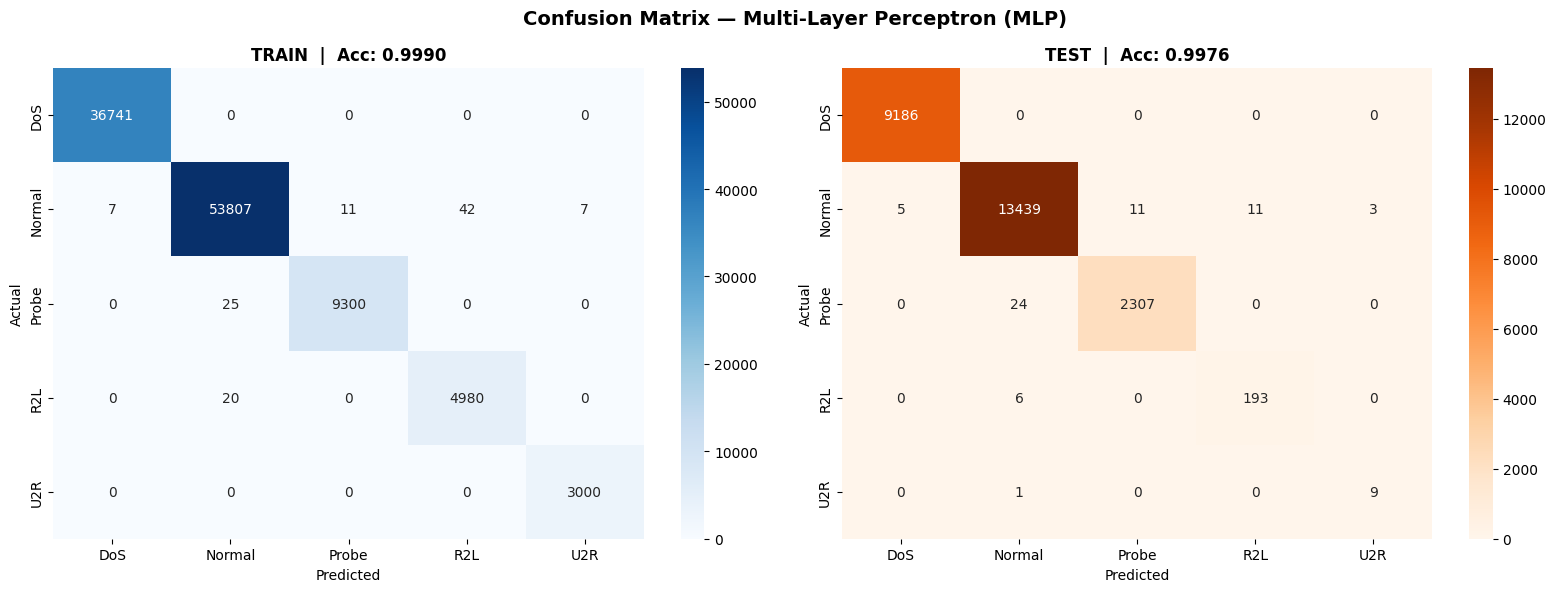

In [139]:
# ════════════════════════════════════════════════════════════════
# STEP 3: CONFUSION MATRICES - MLP ONLY
# ════════════════════════════════════════════════════════════════

print("\n— STEP 3: Confusion Matrices (MLP Only) —")

# Extract MLP results directly
mlp_res = results_w4['MLP']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Confusion Matrix — Multi-Layer Perceptron (MLP)', 
             fontweight='bold', fontsize=14)

# 1. Train Confusion Matrix
cm_train = confusion_matrix(y_train_w4, mlp_res['y_pred_train'])
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_multi.classes_,
            yticklabels=le_multi.classes_,
            ax=axes[0])
axes[0].set_title(f'TRAIN  |  Acc: {mlp_res["train_acc"]:.4f}', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# 2. Test Confusion Matrix
cm_test = confusion_matrix(y_test_w4, mlp_res['y_pred_test'])
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le_multi.classes_,
            yticklabels=le_multi.classes_,
            ax=axes[1])
axes[1].set_title(f'TEST  |  Acc: {mlp_res["test_acc"]:.4f}', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

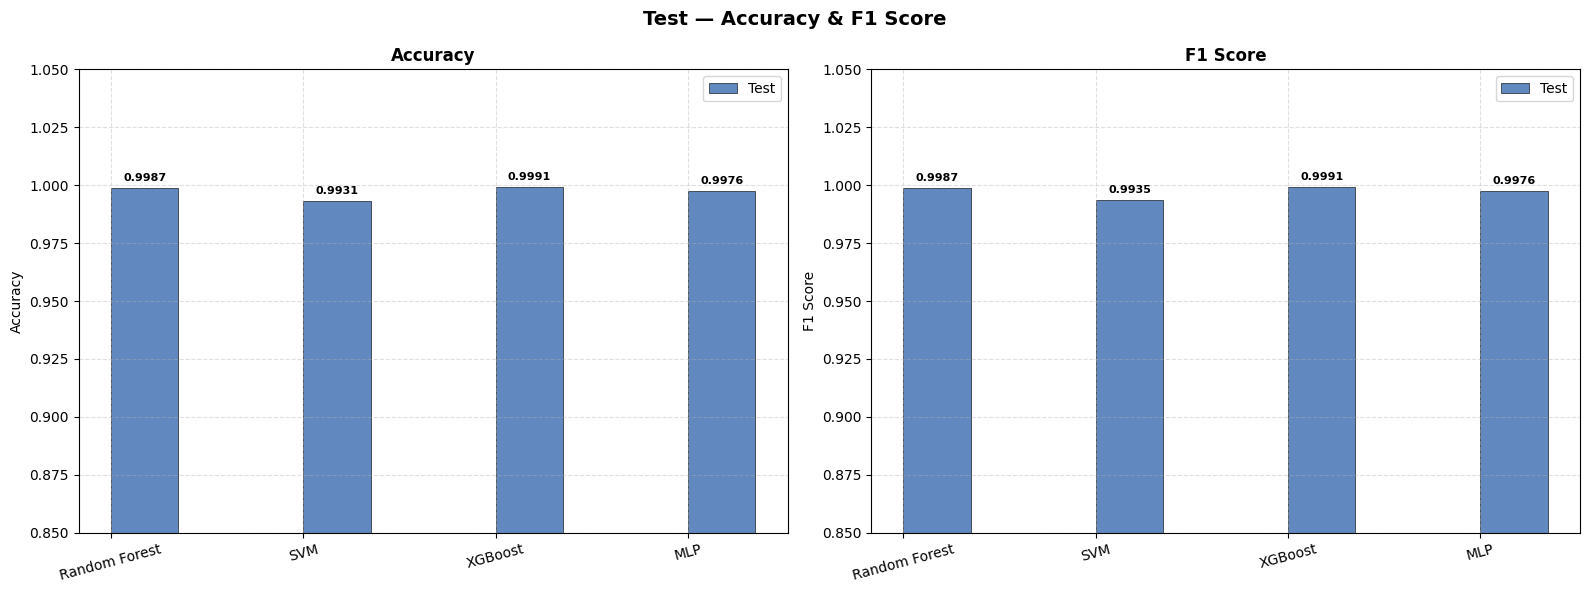

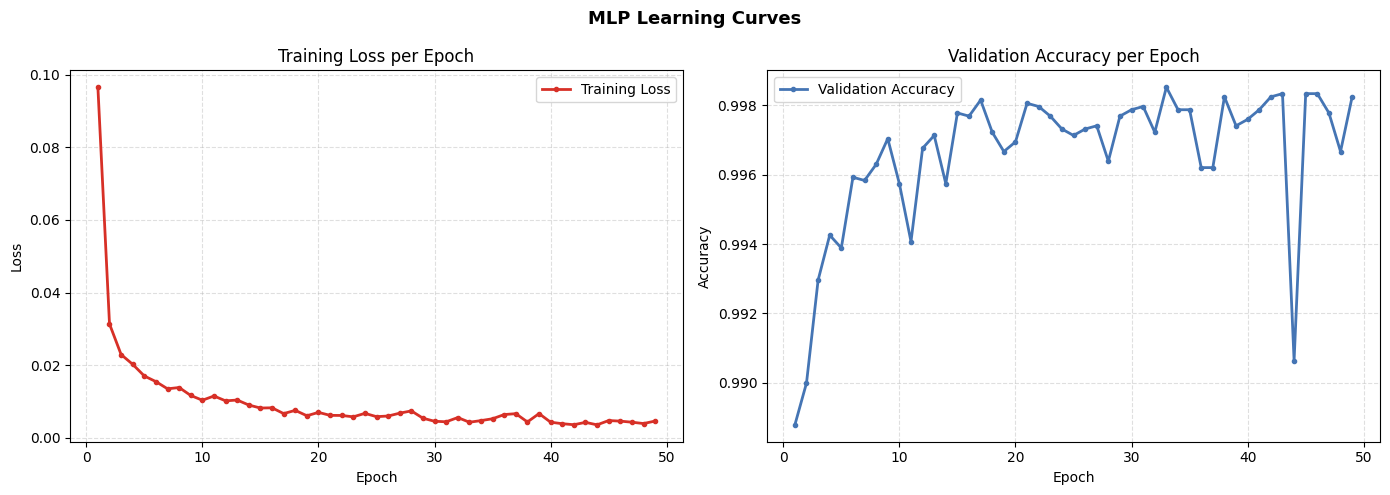

In [141]:
# ════════════════════════════════════════════════════════════════
# STEP 4: COMPARISON GRAPHS
# ════════════════════════════════════════════════════════════════

names_w4   = list(results_w4.keys())
train_accs = [results_w4[n]['train_acc'] for n in names_w4]
test_accs  = [results_w4[n]['test_acc']  for n in names_w4]
train_f1s  = [results_w4[n]['train_f1']  for n in names_w4]
test_f1s   = [results_w4[n]['test_f1']   for n in names_w4]
gaps       = [results_w4[n]['gap']        for n in names_w4]

x     = np.arange(len(names_w4))
width = 0.35

# Test Accuracy and F1 ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Test — Accuracy & F1 Score',
             fontweight='bold', fontsize=14)

for ax, (te_vals, metric) in zip(axes, [
    (test_accs, 'Accuracy'),
    (test_f1s,  'F1 Score'),
]):
   
    ax.bar(x + width/2, te_vals, width, color='#4575b4',
           alpha=0.85, label='Test',  edgecolor='black', linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(names_w4, rotation=15)
    ax.set_ylim(0.85, 1.05)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylabel(metric)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.4)
    for i, te in enumerate(te_vals):
        ax.text(i + width/2, te + 0.003, f'{te:.4f}',
                ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('week4_test.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Graph 5: MLP learning curve ──
mlp_model    = results_w4['MLP']['model']
train_losses = mlp_model.loss_curve_
val_scores   = mlp_model.validation_scores_
epochs       = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MLP Learning Curves', fontweight='bold', fontsize=13)

axes[0].plot(epochs, train_losses, color='#d73027',
             linewidth=2, marker='o', markersize=3,
             label='Training Loss')
axes[0].set_title('Training Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.4)

axes[1].plot(epochs, val_scores, color='#4575b4',
             linewidth=2, marker='o', markersize=3,
             label='Validation Accuracy')
axes[1].set_title('Validation Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('week4_mlp_learning_curve.png', dpi=120, bbox_inches='tight')
plt.show()